In [ ]:
# -*- coding: utf-8 -*-
"""
优化的电荷转移预测系统 - 基于 SMILES 的多模型集成预测
（完整版本：包含目标变量标准化、保存所有模型、预测值还原，并确保预测值在 [-2, 2] eV 范围内）
"""

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor, StackingRegressor, AdaBoostRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.feature_selection import SelectFromModel, RFE, SelectKBest, f_regression, mutual_info_regression
from sklearn.decomposition import PCA, KernelPCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.kernel_ridge import KernelRidge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
import xgboost as xgb
import lightgbm as lgb
import catboost as cb
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import datetime
import os
import joblib
import optuna
from scipy.stats import pearsonr, spearmanr
from scipy import stats
import shap
warnings.filterwarnings('ignore')

# RDKit 导入
try:
    from rdkit import Chem
    from rdkit.Chem import AllChem, Descriptors, rdMolDescriptors, MACCSkeys
    from rdkit.ML.Descriptors import MoleculeDescriptors
    RDKIT_AVAILABLE = True
except ImportError:
    RDKIT_AVAILABLE = False
    print("警告: RDKit 未安装，将使用简化特征提取（但本代码需要 RDKit）")

class AdvancedCharge_Predictor_Optimized:
    def __init__(self, data_path, output_path):
        self.data_path = data_path
        self.output_path = output_path
        os.makedirs(output_path, exist_ok=True)

        self.models = {}
        self.results = {}
        self.feature_importance = {}
        self.dim_reduction_method = None
        self.dim_reducer = None          # 降维器
        self.selected_feature_indices = None
        self.y_scaler = None             # 目标变量标准化器
        self.best_model = None
        self.feature_names = []
        
        # 新增：电荷转移物理范围（单位：eV）
        self.target_range = (-2.0, 2.0)

    def load_data(self):
        """加载数据"""
        print(f"加载数据: {self.data_path}")
        try:
            if self.data_path.endswith('.xlsx') or self.data_path.endswith('.xls'):
                df = pd.read_excel(self.data_path)
            else:
                df = pd.read_csv(self.data_path)
        except Exception as e:
            print(f"数据加载失败: {e}")
            return None
        print(f"数据集形状: {df.shape}")
        print(f"列名: {list(df.columns)}")
        print("\n数据预览:")
        print(df.head())
        print(f"\n缺失值统计:")
        print(df.isnull().sum())
        return df

    def extended_feature_engineering(self, smiles_list):
        """扩展特征工程"""
        print("执行扩展特征工程...")
        features = []
        valid_indices = []
        descriptor_names = [x[0] for x in Descriptors._descList]

        for i, smiles in enumerate(smiles_list):
            try:
                mol = Chem.MolFromSmiles(str(smiles))
                if mol is None:
                    continue

                # 多种指纹
                fp1 = AllChem.GetMorganFingerprintAsBitVect(mol, 1, nBits=256)
                fp2 = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=256)
                fp3 = AllChem.GetMorganFingerprintAsBitVect(mol, 3, nBits=128)
                rdk_fp = Chem.RDKFingerprint(mol, fpSize=256)
                maccs = MACCSkeys.GenMACCSKeys(mol)
                ap_fp = AllChem.GetHashedAtomPairFingerprintAsBitVect(mol, nBits=256)
                tt_fp = AllChem.GetHashedTopologicalTorsionFingerprintAsBitVect(mol, nBits=256)

                # 基础描述符
                calc = MoleculeDescriptors.MolecularDescriptorCalculator(descriptor_names)
                desc = calc.CalcDescriptors(mol)

                # 高级描述符
                adv_desc = []
                try:
                    adv_desc.extend([
                        rdMolDescriptors.CalcAsphericity(mol),
                        rdMolDescriptors.CalcEccentricity(mol),
                        rdMolDescriptors.CalcInertialShapeFactor(mol),
                        rdMolDescriptors.CalcNPR1(mol),
                        rdMolDescriptors.CalcNPR2(mol),
                        rdMolDescriptors.CalcPMI1(mol),
                        rdMolDescriptors.CalcPMI2(mol),
                        rdMolDescriptors.CalcPMI3(mol),
                        rdMolDescriptors.CalcRadiusOfGyration(mol),
                        rdMolDescriptors.CalcHallKierAlpha(mol),
                        rdMolDescriptors.CalcKappa1(mol),
                        rdMolDescriptors.CalcKappa2(mol),
                        rdMolDescriptors.CalcKappa3(mol),
                        rdMolDescriptors.CalcNumAromaticRings(mol),
                        rdMolDescriptors.CalcNumAliphaticRings(mol),
                        rdMolDescriptors.CalcNumHeterocycles(mol),
                        rdMolDescriptors.CalcNumBridgeheadAtoms(mol),
                        rdMolDescriptors.CalcNumSpiroAtoms(mol)
                    ])
                except:
                    adv_desc = [0]*18

                # 图特征
                graph_feat = []
                try:
                    adj = Chem.GetAdjacencyMatrix(mol)
                    degree = np.sum(adj, axis=1)
                    graph_feat.extend([np.mean(degree), np.std(degree), np.max(degree), np.min(degree)])
                    ring_info = mol.GetRingInfo()
                    graph_feat.append(ring_info.NumRings())
                    atoms = [atom.GetAtomicNum() for atom in mol.GetAtoms()]
                    graph_feat.append(len(set(atoms)))
                except:
                    graph_feat = [0]*6

                # 碎片特征
                frag_feat = []
                try:
                    frag_feat.extend([
                        Chem.Fragments.fr_Al_COO(mol),
                        Chem.Fragments.fr_Al_OH(mol),
                        Chem.Fragments.fr_ArN(mol),
                        Chem.Fragments.fr_COO(mol),
                        Chem.Fragments.fr_C_O(mol),
                        Chem.Fragments.fr_NH2(mol),
                        Chem.Fragments.fr_OH(mol),
                        Chem.Fragments.fr_SH(mol),
                        Chem.Fragments.fr_aldehyde(mol),
                        Chem.Fragments.fr_ketone(mol),
                        Chem.Fragments.fr_ester(mol),
                        Chem.Fragments.fr_ether(mol),
                        Chem.Fragments.fr_amide(mol)
                    ])
                except:
                    frag_feat = [0]*13

                # 合并
                combined = np.concatenate([
                    np.array(fp1), np.array(fp2), np.array(fp3),
                    np.array(rdk_fp), np.array(maccs), np.array(ap_fp), np.array(tt_fp),
                    np.array(desc), np.array(adv_desc), np.array(graph_feat), np.array(frag_feat)
                ])
                combined = np.nan_to_num(combined, nan=0.0, posinf=0.0, neginf=0.0)

                features.append(combined)
                valid_indices.append(i)
            except Exception as e:
                print(f"处理 SMILES {smiles} 时出错: {e}")
                continue

        if not features:
            raise ValueError("没有成功提取任何分子的特征")

        return np.array(features), valid_indices

    def advanced_feature_selection(self, X, y, n_features=200):
        """高级特征选择"""
        print(f"\n执行高级特征选择，目标特征数: {n_features}")
        # MI 选择
        mi_scores = mutual_info_regression(X, y, random_state=42)
        mi_indices = np.argsort(mi_scores)[-n_features:]

        # 相关性选择
        corr_scores = []
        for i in range(X.shape[1]):
            if np.std(X[:, i]) > 0:
                corr, _ = pearsonr(X[:, i], y)
                corr_scores.append(abs(corr))
            else:
                corr_scores.append(0)
        corr_indices = np.argsort(corr_scores)[-n_features:]

        # XGBoost 重要性
        xgb_model = xgb.XGBRegressor(random_state=42, n_jobs=-1)
        xgb_model.fit(X, y)
        xgb_importances = xgb_model.feature_importances_
        xgb_indices = np.argsort(xgb_importances)[-n_features:]

        # Lasso 选择
        lasso = Lasso(alpha=0.001, max_iter=10000, random_state=42)
        lasso.fit(X, y)
        lasso_indices = np.where(np.abs(lasso.coef_) > 1e-6)[0]
        if len(lasso_indices) > n_features:
            lasso_coefs = np.abs(lasso.coef_[lasso_indices])
            lasso_indices = lasso_indices[np.argsort(lasso_coefs)[-n_features:]]

        # 合并索引
        all_selected = set()
        for idx in [mi_indices, corr_indices, xgb_indices]:
            all_selected.update(idx)
        if len(lasso_indices) > 0:
            all_selected.update(lasso_indices)

        # 确保数量
        if len(all_selected) < n_features:
            remaining = set(range(X.shape[1])) - all_selected
            extra = np.random.choice(list(remaining), min(len(remaining), n_features - len(all_selected)), replace=False)
            all_selected.update(extra)

        selected = list(all_selected)[:n_features]
        X_selected = X[:, selected]
        print(f"从 {X.shape[1]} 个特征中选择 {X_selected.shape[1]} 个")
        return X_selected, selected

    def apply_advanced_dimensionality_reduction(self, X, y, n_components=None):
        """
        高级降维，返回 (降维后数据, 方法名, 降维器对象)
        """
        if n_components is None:
            n_components = min(50, X.shape[0]//2, X.shape[1]//3)

        print(f"\n应用高级降维，目标维度: {n_components}")

        # 标准化
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        methods = {}
        reducers = {}

        # PCA
        pca = PCA(n_components=n_components, random_state=42)
        X_pca = pca.fit_transform(X_scaled)
        methods['PCA'] = X_pca
        reducers['PCA'] = pca
        print(f"PCA 解释方差比: {np.sum(pca.explained_variance_ratio_):.4f}")

        # KernelPCA
        try:
            kpca = KernelPCA(n_components=n_components, kernel='rbf', random_state=42)
            X_kpca = kpca.fit_transform(X_scaled)
            methods['KernelPCA'] = X_kpca
            reducers['KernelPCA'] = kpca
        except Exception as e:
            print(f"KernelPCA 失败: {e}，跳过")

        # PLS
        pls = PLSRegression(n_components=n_components)
        X_pls = pls.fit_transform(X_scaled, y)[0]
        methods['PLS'] = X_pls
        reducers['PLS'] = pls

        # 评估各方法
        best_score = -np.inf
        best_X = X_pca
        best_method = 'PCA'
        best_reducer = pca

        for name, X_red in methods.items():
            try:
                scores = cross_val_score(Ridge(), X_red, y, cv=5, scoring='r2', n_jobs=-1)
                mean_score = scores.mean()
                print(f"{name} - 平均 R²: {mean_score:.4f}")
                if mean_score > best_score:
                    best_score = mean_score
                    best_X = X_red
                    best_method = name
                    best_reducer = reducers[name]
            except Exception as e:
                print(f"评估 {name} 时出错: {e}")

        print(f"选定的降维方法: {best_method}, R²: {best_score:.4f}")
        return best_X, best_method, best_reducer

    def create_interaction_features(self, X):
        """创建交互特征（平方项 + 两两乘积项）"""
        print("创建交互特征...")
        n_samples, n_features = X.shape
        n_inter = min(10, n_features)
        inter_features = []
        for i in range(n_inter):
            inter_features.append(X[:, i] ** 2)
        for i in range(n_inter):
            for j in range(i+1, n_inter):
                inter_features.append(X[:, i] * X[:, j])
        if inter_features:
            X_inter = np.column_stack(inter_features)
            X_comb = np.hstack([X, X_inter])
            print(f"添加 {X_inter.shape[1]} 个交互特征，总特征数: {X_comb.shape[1]}")
            return X_comb
        else:
            return X

    def prepare_optimized_features(self, df):
        """准备优化特征，并对目标变量进行标准化"""
        print("\n准备优化特征...")
        columns = df.columns.tolist()
        smiles_col = next((col for col in columns if 'smile' in col.lower()), columns[0])
        charge_col = next((col for col in columns if 'charge' in col.lower()), 
                          columns[1] if len(columns) > 1 else None)
        if charge_col is None:
            raise ValueError("无法确定电荷转移列")

        smiles_list = df[smiles_col].astype(str).tolist()
        charge_values = pd.to_numeric(df[charge_col], errors='coerce').values
        valid_mask = ~np.isnan(charge_values)
        smiles_list = [smiles_list[i] for i in range(len(smiles_list)) if valid_mask[i]]
        charge_values = charge_values[valid_mask]

        print(f"SMILES 列: {smiles_col}, 电荷列: {charge_col}")
        print(f"有效样本数: {len(smiles_list)}")

        if not RDKIT_AVAILABLE:
            raise ImportError("RDKit 不可用，无法进行特征工程")

        X, valid_indices = self.extended_feature_engineering(smiles_list)
        y = charge_values[valid_indices]
        print(f"特征工程后维度: {X.shape}")

        X = self.create_interaction_features(X)

        # 根据样本量选择处理方法
        if X.shape[0] < 200:   # 小样本 -> 降维
            print("检测到小数据集，使用降维...")
            X_processed, method, reducer = self.apply_advanced_dimensionality_reduction(X, y)
            self.dim_reduction_method = method
            self.dim_reducer = reducer          # 保存降维器
        else:                   # 大样本 -> 特征选择
            X_processed, selected_indices = self.advanced_feature_selection(X, y, n_features=min(200, X.shape[1]))
            self.selected_feature_indices = selected_indices

        # 对目标变量进行标准化
        y_scaler = StandardScaler()
        y_scaled = y_scaler.fit_transform(y.reshape(-1, 1)).ravel()
        self.y_scaler = y_scaler

        print(f"最终特征维度: {X_processed.shape}")
        print(f"目标变量标准化后: mean={y_scaled.mean():.4f}, std={y_scaled.std():.4f}")

        y_stats = {
            'mean': y.mean(),
            'std': y.std(),
            'min': y.min(),
            'max': y.max(),
            'median': np.median(y),
            'skewness': stats.skew(y),
            'kurtosis': stats.kurtosis(y)
        }
        print("电荷转移原始统计:")
        for k, v in y_stats.items():
            print(f"  {k}: {v:.4f}")

        return X_processed, y_scaled, smiles_list   # 返回标准化后的 y

    def initialize_optimized_models(self):
        """初始化优化模型集合"""
        print("\n初始化优化模型集合...")
        base_models = {
            'RandomForest': RandomForestRegressor(n_estimators=300, max_depth=15,
                min_samples_split=5, min_samples_leaf=2, max_features='sqrt',
                bootstrap=True, random_state=42, n_jobs=-1),
            'GradientBoosting': GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                max_depth=5, min_samples_split=5, min_samples_leaf=2, subsample=0.8, random_state=42),
            'XGBoost': xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1),
            'LightGBM': lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, num_leaves=31,
                subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, verbose=-1),
            'CatBoost': cb.CatBoostRegressor(iterations=300, learning_rate=0.05, depth=6,
                l2_leaf_reg=3, random_seed=42, verbose=0),
            'SVR_rbf': SVR(kernel='rbf', C=10, epsilon=0.1, gamma='scale'),
            'SVR_poly': SVR(kernel='poly', degree=3, C=10, epsilon=0.1),
            'Ridge': Ridge(alpha=1.0, random_state=42),
            'Lasso': Lasso(alpha=0.001, max_iter=10000, random_state=42),
            'ElasticNet': ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10000, random_state=42),
            'KernelRidge': KernelRidge(alpha=1.0, kernel='rbf', gamma=0.1),
            'PLS': PLSRegression(n_components=5),
            'AdaBoost': AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=5),
                n_estimators=200, learning_rate=0.1, random_state=42),
            'ExtraTrees': ExtraTreesRegressor(n_estimators=300, max_depth=15,
                min_samples_split=5, min_samples_leaf=2, random_state=42, n_jobs=-1),
            'KNN': KNeighborsRegressor(n_neighbors=5, weights='distance', n_jobs=-1),
            'MLP': MLPRegressor(hidden_layer_sizes=(100,50), activation='relu',
                solver='adam', alpha=0.001, learning_rate='adaptive', max_iter=1000,
                random_state=42, early_stopping=True, validation_fraction=0.1)
        }
        estimators = [
            ('xgb', base_models['XGBoost']),
            ('lgb', base_models['LightGBM']),
            ('rf', base_models['RandomForest']),
            ('et', base_models['ExtraTrees'])
        ]
        advanced_models = {
            'VotingRegressor': VotingRegressor(estimators=[
                ('xgb', base_models['XGBoost']),
                ('lgb', base_models['LightGBM']),
                ('rf', base_models['RandomForest'])
            ]),
            'StackingRegressor': StackingRegressor(
                estimators=estimators,
                final_estimator=xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42),
                cv=5, passthrough=False
            )
        }
        self.models = {**base_models, **advanced_models}
        self.param_grids = {
            'RandomForest': {'n_estimators': [100,200,300], 'max_depth': [10,15,20],
                'min_samples_split': [2,5], 'min_samples_leaf': [1,2]},
            'XGBoost': {'n_estimators': [100,200,300], 'learning_rate': [0.01,0.05,0.1],
                'max_depth': [4,6,8], 'subsample': [0.7,0.8], 'colsample_bytree': [0.7,0.8]},
            'LightGBM': {'n_estimators': [100,200,300], 'learning_rate': [0.01,0.05,0.1],
                'num_leaves': [31,50], 'subsample': [0.7,0.8], 'colsample_bytree': [0.7,0.8]},
            'SVR_rbf': {'C': [0.1,1,10], 'epsilon': [0.01,0.1], 'gamma': ['scale','auto']},
            'MLP': {'hidden_layer_sizes': [(50,),(100,),(100,50)], 'activation': ['relu','tanh'],
                'alpha': [0.0001,0.001]}
        }
        print(f"初始化了 {len(self.models)} 个模型")

    def advanced_data_augmentation(self, X_train, y_train):
        """数据增强"""
        print("应用数据增强...")
        X_aug = [X_train]
        y_aug = [y_train]
        if X_train.shape[0] < 100:
            noise = 0.01
            X_noisy = X_train + np.random.normal(0, noise, X_train.shape) * np.std(X_train, axis=0)
            X_aug.append(X_noisy)
            y_aug.append(y_train)
        X_aug = np.vstack(X_aug)
        y_aug = np.hstack(y_aug)
        print(f"数据增强后: {X_train.shape[0]} -> {X_aug.shape[0]} 样本")
        return X_aug, y_aug

    def optimize_with_optuna(self, model_name, X, y):
        """Optuna 超参数优化"""
        print(f"使用 Optuna 优化 {model_name}...")
        if model_name == 'XGBoost':
            def objective(trial):
                params = {
                    'n_estimators': trial.suggest_int('n_estimators', 50, 500),
                    'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
                    'max_depth': trial.suggest_int('max_depth', 3, 10),
                    'subsample': trial.suggest_uniform('subsample', 0.6, 1.0),
                    'colsample_bytree': trial.suggest_uniform('colsample_bytree', 0.6, 1.0),
                    'gamma': trial.suggest_loguniform('gamma', 1e-8, 1.0),
                    'reg_alpha': trial.suggest_loguniform('reg_alpha', 1e-8, 1.0),
                    'reg_lambda': trial.suggest_loguniform('reg_lambda', 1e-8, 1.0),
                    'random_state': 42
                }
                model = xgb.XGBRegressor(**params, n_jobs=-1)
                scores = cross_val_score(model, X, y, cv=5, scoring='r2', n_jobs=-1)
                return scores.mean()
        elif model_name == 'LightGBM':
            def objective(trial):
                params = {
                    'n_estimators': trial.suggest_int('n_estimators', 50, 500),
                    'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
                    'num_leaves': trial.suggest_int('num_leaves', 20, 100),
                    'subsample': trial.suggest_uniform('subsample', 0.6, 1.0),
                    'colsample_bytree': trial.suggest_uniform('colsample_bytree', 0.6, 1.0),
                    'reg_alpha': trial.suggest_loguniform('reg_alpha', 1e-8, 1.0),
                    'reg_lambda': trial.suggest_loguniform('reg_lambda', 1e-8, 1.0),
                    'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
                    'random_state': 42,
                    'verbose': -1
                }
                model = lgb.LGBMRegressor(**params, n_jobs=-1)
                scores = cross_val_score(model, X, y, cv=5, scoring='r2', n_jobs=-1)
                return scores.mean()
        else:
            return None

        try:
            study = optuna.create_study(direction='maximize')
            study.optimize(objective, n_trials=30, timeout=300)
            print(f"最佳参数: {study.best_params}")
            print(f"最佳 R²: {study.best_value:.4f}")
            return study.best_params
        except Exception as e:
            print(f"Optuna 优化失败: {e}，使用默认参数")
            return None

    def train_optimized_models(self, X_train, X_test, y_train, y_test):
        """训练优化模型（使用标准化后的 y）"""
        print("\n开始优化模型训练...")
        print("=" * 80)
        results = {}
        if X_train.shape[0] < 200:
            X_train_aug, y_train_aug = self.advanced_data_augmentation(X_train, y_train)
        else:
            X_train_aug, y_train_aug = X_train, y_train

        for name, model in self.models.items():
            print(f"\n训练 {name} 模型...")
            print("-" * 40)
            try:
                if name in ['SVR_rbf','SVR_poly','Ridge','Lasso','ElasticNet','KernelRidge','PLS','MLP','KNN']:
                    scaler = StandardScaler()
                    X_train_scaled = scaler.fit_transform(X_train_aug)
                    X_test_scaled = scaler.transform(X_test)
                    X_tr = X_train_scaled
                    X_te = X_test_scaled
                else:
                    scaler = None
                    X_tr = X_train_aug
                    X_te = X_test

                # Optuna 优化
                if name in ['XGBoost','LightGBM'] and X_train_aug.shape[0] >= 50:
                    best_params = self.optimize_with_optuna(name, X_tr, y_train_aug)
                    if best_params:
                        if name == 'XGBoost':
                            model = xgb.XGBRegressor(**best_params, n_jobs=-1, random_state=42)
                        elif name == 'LightGBM':
                            model = lgb.LGBMRegressor(**best_params, n_jobs=-1, random_state=42, verbose=-1)

                # GridSearch
                if name in self.param_grids and X_train_aug.shape[0] >= 50:
                    print(f"对 {name} 进行网格搜索...")
                    try:
                        grid = GridSearchCV(model, self.param_grids[name],
                                            cv=min(5, X_train_aug.shape[0]//5),
                                            scoring='r2', n_jobs=-1, verbose=0)
                        grid.fit(X_tr, y_train_aug)
                        best_model = grid.best_estimator_
                        best_params = grid.best_params_
                        best_score = grid.best_score_
                    except Exception as e:
                        print(f"网格搜索失败: {e}，使用默认模型")
                        best_model = model.fit(X_tr, y_train_aug)
                        best_params = "使用默认参数"
                        best_score = cross_val_score(best_model, X_tr, y_train_aug, cv=5, scoring='r2').mean()
                else:
                    best_model = model.fit(X_tr, y_train_aug)
                    best_params = "使用默认参数"
                    best_score = cross_val_score(best_model, X_tr, y_train_aug, cv=5, scoring='r2').mean()

                y_pred_train = best_model.predict(X_tr)
                y_pred_test = best_model.predict(X_te)
                train_r2 = r2_score(y_train_aug, y_pred_train)
                test_r2 = r2_score(y_test, y_pred_test)
                train_rmse = np.sqrt(mean_squared_error(y_train_aug, y_pred_train))
                test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
                train_mae = mean_absolute_error(y_train_aug, y_pred_train)
                test_mae = mean_absolute_error(y_test, y_pred_test)

                cv_scores = cross_val_score(best_model, X_tr, y_train_aug, cv=5, scoring='r2', n_jobs=-1)
                cv_rmse = cross_val_score(best_model, X_tr, y_train_aug, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
                cv_mae = cross_val_score(best_model, X_tr, y_train_aug, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)

                overfitting_gap = train_r2 - test_r2

                results[name] = {
                    'model': best_model,
                    'scaler': scaler,
                    'best_params': best_params,
                    'best_cv_score': best_score,
                    'train_r2': train_r2,
                    'test_r2': test_r2,
                    'train_rmse': train_rmse,
                    'test_rmse': test_rmse,
                    'train_mae': train_mae,
                    'test_mae': test_mae,
                    'overfitting_gap': overfitting_gap,
                    'cv_r2_mean': cv_scores.mean() if len(cv_scores)>0 else 0,
                    'cv_r2_std': cv_scores.std() if len(cv_scores)>0 else 0,
                    'cv_rmse_mean': -cv_rmse.mean() if len(cv_rmse)>0 else 0,
                    'cv_mae_mean': -cv_mae.mean() if len(cv_mae)>0 else 0,
                    'y_pred_train': y_pred_train,
                    'y_pred_test': y_pred_test
                }

                print(f"最佳 CV R²: {best_score:.4f}")
                print(f"训练 R²: {train_r2:.4f}, 测试 R²: {test_r2:.4f}")
                print(f"过拟合 gap: {overfitting_gap:.4f}")
                print(f"交叉验证 R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

                if test_r2 > 0.9:
                    print("✓ 达到 R² > 0.9 目标！")
                elif test_r2 > 0.85:
                    print("✓ 接近目标 (R² > 0.85)")
            except Exception as e:
                print(f"训练 {name} 时出错: {e}")
                continue

        self.results = results
        return results

    def create_meta_features(self, X, results, is_train=False):
        """创建元特征"""
        print("创建元特征...")
        meta_feats = []
        sorted_models = sorted(results.items(), key=lambda x: x[1]['test_r2'] if x[1]['test_r2'] is not None else -np.inf, reverse=True)[:5]
        for name, res in sorted_models:
            if is_train and 'y_pred_train' in res:
                meta_feats.append(res['y_pred_train'])
            elif not is_train and 'y_pred_test' in res:
                meta_feats.append(res['y_pred_test'])
        if meta_feats:
            X_meta = np.column_stack(meta_feats)
            if X_meta.shape[0] == X.shape[0]:
                X_enhanced = np.hstack([X, X_meta])
                print(f"添加 {X_meta.shape[1]} 个元特征，总特征数: {X_enhanced.shape[1]}")
                return X_enhanced
            else:
                print(f"警告: 元特征维度不匹配，跳过")
                return X
        else:
            return X

    def select_best_ensemble(self, results, X_test, y_test):
        """选择最佳集成方法"""
        print("\n选择最佳集成策略...")
        sorted_models = sorted(results.items(), key=lambda x: x[1]['test_r2'] if x[1]['test_r2'] is not None else -np.inf, reverse=True)[:5]
        weights = []
        preds = []
        names = []
        for name, res in sorted_models:
            if 'y_pred_test' in res and res['test_r2'] is not None and res['test_r2'] > 0:
                weights.append(res['test_r2'])
                preds.append(res['y_pred_test'])
                names.append(name)
        if len(weights) >= 2:
            weights = np.array(weights) / sum(weights)
            weighted_avg = np.zeros_like(preds[0])
            for p, w in zip(preds, weights):
                weighted_avg += p * w
            weighted_r2 = r2_score(y_test, weighted_avg)
            weighted_rmse = np.sqrt(mean_squared_error(y_test, weighted_avg))

            median_pred = np.median(preds, axis=0)
            median_r2 = r2_score(y_test, median_pred)
            median_rmse = np.sqrt(mean_squared_error(y_test, median_pred))

            if weighted_r2 >= median_r2:
                best_pred = weighted_avg
                best_r2 = weighted_r2
                best_rmse = weighted_rmse
                best_method = 'WeightedAverage'
            else:
                best_pred = median_pred
                best_r2 = median_r2
                best_rmse = median_rmse
                best_method = 'MedianEnsemble'

            print(f"集成方法比较:")
            print(f"  加权平均: R² = {weighted_r2:.4f}, RMSE = {weighted_rmse:.4f}")
            print(f"  中位数集成: R² = {median_r2:.4f}, RMSE = {median_rmse:.4f}")
            print(f"选定的最佳集成方法: {best_method}")
            return {
                'name': best_method,
                'predictions': best_pred,
                'test_r2': best_r2,
                'test_rmse': best_rmse,
                'weights': weights if best_method == 'WeightedAverage' else None,
                'model_names': names
            }
        return None

    def save_best_model(self, best_model_name, best_result, n_features):
        """保存最佳模型（包含 y_scaler）"""
        print("\n保存最佳模型...")
        model_info = {
            'best_model_name': best_model_name,
            'model': best_result['model'],
            'scaler': best_result['scaler'],
            'y_scaler': self.y_scaler,                # 保存目标变量标准化器
            'best_params': best_result['best_params'],
            'test_r2': best_result['test_r2'],
            'test_rmse': best_result['test_rmse'],
            'test_mae': best_result['test_mae'],
            'feature_dimension': n_features,
            'timestamp': datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        }
        # 保存特征选择索引
        if hasattr(self, 'selected_feature_indices') and self.selected_feature_indices is not None:
            model_info['selected_feature_indices'] = self.selected_feature_indices
        # 保存降维器
        if hasattr(self, 'dim_reducer') and self.dim_reducer is not None:
            model_info['dim_reducer'] = self.dim_reducer
            model_info['dim_reduction_method'] = self.dim_reduction_method

        model_path = os.path.join(self.output_path, 'best_optimized_model.pkl')
        joblib.dump(model_info, model_path)
        print(f"最佳模型已保存至: {model_path}")
        return model_info

    def save_optimized_results(self, df, X, y_scaled, smiles_list, X_test, y_test, ensemble_result):
        """
        保存优化结果，并对预测值进行逆标准化和截断，确保在物理范围内
        y_scaled: 标准化后的目标变量（训练时使用）
        y_test: 标准化后的测试集目标值（用于计算指标）
        """
        print("保存优化分析结果...")
        results_data = []
        for name, res in self.results.items():
            results_data.append({
                'Model': name,
                'Train_R2': res['train_r2'],
                'Test_R2': res['test_r2'],
                'Train_RMSE': res['train_rmse'],
                'Test_RMSE': res['test_rmse'],
                'Train_MAE': res['train_mae'],
                'Test_MAE': res['test_mae'],
                'Overfitting_Gap': res['overfitting_gap'],
                'CV_R2_Mean': res['cv_r2_mean'],
                'CV_R2_Std': res['cv_r2_std'],
                'CV_RMSE_Mean': res['cv_rmse_mean'],
                'CV_MAE_Mean': res['cv_mae_mean'],
                'Best_Params': str(res['best_params'])[:200]
            })
        if ensemble_result:
            results_data.append({
                'Model': ensemble_result['name'],
                'Train_R2': None,
                'Test_R2': ensemble_result['test_r2'],
                'Train_RMSE': None,
                'Test_RMSE': ensemble_result['test_rmse'],
                'Train_MAE': None,
                'Test_MAE': None,
                'Overfitting_Gap': 0,
                'CV_R2_Mean': ensemble_result['test_r2'],
                'CV_R2_Std': 0,
                'CV_RMSE_Mean': ensemble_result['test_rmse'],
                'CV_MAE_Mean': None,
                'Best_Params': f"集成模型: {', '.join(ensemble_result['model_names'])}"
            })
        results_df = pd.DataFrame(results_data).sort_values('Test_R2', ascending=False)
        results_df.to_csv(os.path.join(self.output_path, 'optimized_model_performance.csv'), index=False, encoding='utf-8-sig')

        # 保存详细预测结果（逆标准化 + 截断）
        best_name = max(self.results.keys(), key=lambda x: self.results[x]['test_r2'] if self.results[x]['test_r2'] is not None else -np.inf)
        best_res = self.results[best_name]

        # 对整个特征集 X 进行预测，并逆标准化
        if best_res['scaler'] is not None:
            X_scaled = best_res['scaler'].transform(X)
            pred_scaled = best_res['model'].predict(X_scaled)
        else:
            pred_scaled = best_res['model'].predict(X)

        # 逆标准化预测值
        if self.y_scaler is not None:
            pred_original = self.y_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()
        else:
            pred_original = pred_scaled

        # 新增：将预测值限制在物理范围内 [-2, 2] eV
        pred_original = np.clip(pred_original, self.target_range[0], self.target_range[1])

        # 原始目标值也需要逆标准化
        y_original = self.y_scaler.inverse_transform(y_scaled.reshape(-1, 1)).ravel() if self.y_scaler is not None else y_scaled

        pred_df = pd.DataFrame({
            'SMILES': smiles_list,
            'Actual_Charge': y_original,
            'Predicted_Charge': pred_original,
            'Residual': y_original - pred_original,
            'Absolute_Error': np.abs(y_original - pred_original),
            'Percent_Error': np.abs(y_original - pred_original) / np.abs(y_original) * 100 if np.all(y_original != 0) else np.nan
        })
        pred_df.to_csv(os.path.join(self.output_path, 'optimized_predictions.csv'), index=False, encoding='utf-8-sig')
        print(f"结果已保存至: {self.output_path}")
        return results_df

    def create_optimized_visualizations(self, X_test, y_test, best_model_name, ensemble_result=None):
        """创建可视化（完整版）"""
        print("\n创建优化可视化图表...")
        if not self.results:
            print("无模型结果")
            return
        fig = plt.figure(figsize=(30, 25))

        # 1. 模型性能热图
        ax1 = plt.subplot(4, 4, 1)
        metrics_df = pd.DataFrame({
            'Model': [name for name in self.results.keys()],
            'Test_R2': [self.results[name]['test_r2'] for name in self.results.keys()],
            'Test_RMSE': [self.results[name]['test_rmse'] for name in self.results.keys()],
            'Test_MAE': [self.results[name]['test_mae'] for name in self.results.keys()],
            'Overfitting': [self.results[name]['overfitting_gap'] for name in self.results.keys()],
            'CV_R2': [self.results[name]['cv_r2_mean'] for name in self.results.keys()]
        })
        if len(metrics_df) > 13:
            metrics_df = metrics_df.head(13)
        metrics_matrix = metrics_df.set_index('Model')[['Test_R2', 'Test_RMSE', 'Test_MAE', 'Overfitting', 'CV_R2']]
        sns.heatmap(metrics_matrix, annot=True, fmt='.3f', cmap='RdYlGn', center=0, ax=ax1)
        ax1.set_title('模型性能热图 (Top 13)', fontsize=12, fontweight='bold')
        ax1.tick_params(axis='x', rotation=45)
        ax1.tick_params(axis='y', rotation=0)

        # 2. 最佳模型预测 vs 实际
        ax2 = plt.subplot(4, 4, 2)
        if 'ElasticNet' in self.results:
            best_result = self.results['ElasticNet']
            model_name_display = 'ElasticNet'
        elif best_model_name in self.results:
            best_result = self.results[best_model_name]
            model_name_display = best_model_name
        else:
            first_model = list(self.results.keys())[0]
            best_result = self.results[first_model]
            model_name_display = first_model
        y_pred_test = best_result['y_pred_test']
        ax2.scatter(y_test, y_pred_test, alpha=0.7, s=60, edgecolor='k', linewidth=0.5)
        z = np.polyfit(y_test, y_pred_test, 1)
        p = np.poly1d(z)
        x_line = np.linspace(y_test.min(), y_test.max(), 100)
        ax2.plot(x_line, p(x_line), 'r-', alpha=0.8, linewidth=2, label='回归线')
        min_val = min(y_test.min(), y_pred_test.min())
        max_val = max(y_test.max(), y_pred_test.max())
        ax2.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, linewidth=1, label='完美预测')
        ax2.set_xlabel('实际电荷转移值', fontsize=12)
        ax2.set_ylabel('预测电荷转移值', fontsize=12)
        ax2.set_title(f'{model_name_display} - 预测 vs 实际\nR² = {best_result["test_r2"]:.4f}', fontsize=12, fontweight='bold')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        # 3. 残差分析
        ax3 = plt.subplot(4, 4, 3)
        residuals = y_test - y_pred_test
        ax3.scatter(y_pred_test, residuals, alpha=0.7, s=60, edgecolor='k', linewidth=0.5)
        ax3.axhline(y=0, color='r', linestyle='-', alpha=0.5, linewidth=2)
        ax3.set_xlabel('预测电荷转移值', fontsize=12)
        ax3.set_ylabel('残差', fontsize=12)
        ax3.set_title('残差分布图', fontsize=12, fontweight='bold')
        ax3.grid(True, alpha=0.3)

        # 4. 残差直方图
        ax4 = plt.subplot(4, 4, 4)
        ax4.hist(residuals, bins=20, edgecolor='black', alpha=0.7, density=True)
        ax4.axvline(x=0, color='r', linestyle='--', alpha=0.7, linewidth=2)
        from scipy.stats import norm
        mu, std = norm.fit(residuals)
        x = np.linspace(residuals.min(), residuals.max(), 100)
        p_norm = norm.pdf(x, mu, std)
        ax4.plot(x, p_norm, 'k', linewidth=2, label=f'正态分布\nμ={mu:.3f}, σ={std:.3f}')
        ax4.set_xlabel('残差', fontsize=12)
        ax4.set_ylabel('密度', fontsize=12)
        ax4.set_title('残差直方图', fontsize=12, fontweight='bold')
        ax4.legend()
        ax4.grid(True, alpha=0.3)

        # 5. 雷达图
        ax5 = plt.subplot(4, 4, 5, projection='polar')
        model_names = list(self.results.keys())
        test_r2_scores = [self.results[name]['test_r2'] for name in model_names]
        cv_r2_scores = [self.results[name]['cv_r2_mean'] for name in model_names]
        overfitting_gaps = [1 - min(self.results[name]['overfitting_gap'], 1) for name in model_names]
        angles = np.linspace(0, 2*np.pi, 3, endpoint=False).tolist()
        for i, (name, r2, cv_r2, og) in enumerate(zip(model_names, test_r2_scores, cv_r2_scores, overfitting_gaps)):
            if i < 5:
                radar_values = [r2, cv_r2, og]
                radar_values += radar_values[:1]
                radar_angles = angles + angles[:1]
                ax5.plot(radar_angles, radar_values, 'o-', linewidth=2, label=name[:15])
                ax5.fill(radar_angles, radar_values, alpha=0.1)
        ax5.set_xticks(angles)
        ax5.set_xticklabels(['Test R²', 'CV R²', '泛化能力'])
        ax5.set_title('模型性能雷达图 (Top 5)', fontsize=12, fontweight='bold')
        ax5.legend(bbox_to_anchor=(1.3, 1), loc='upper right')
        ax5.grid(True)

        # 6. ElasticNet 特征重要性
        ax6 = plt.subplot(4, 4, 6)
        if 'ElasticNet' in self.results:
            elasticnet_model = self.results['ElasticNet']['model']
            if hasattr(elasticnet_model, 'coef_'):
                coefficients = elasticnet_model.coef_
                feature_importance = np.abs(coefficients)
                if hasattr(self, 'selected_feature_indices') and self.selected_feature_indices is not None:
                    feature_names = [f'Feature_{i}' for i in self.selected_feature_indices]
                else:
                    feature_names = [f'Feature_{i}' for i in range(len(feature_importance))]
                indices = np.argsort(feature_importance)[::-1]
                sorted_importance = feature_importance[indices]
                sorted_names = [feature_names[i] for i in indices]
                n_top = min(20, len(sorted_importance))
                top_importance = sorted_importance[:n_top]
                top_names = sorted_names[:n_top]
                y_pos = np.arange(n_top)
                bars = ax6.barh(y_pos, top_importance)
                ax6.set_yticks(y_pos)
                ax6.set_yticklabels(top_names, fontsize=8)
                ax6.invert_yaxis()
                ax6.set_xlabel('特征重要性 (|系数|)', fontsize=12)
                ax6.set_title(f'ElasticNet - Top {n_top} 特征重要性', fontsize=12, fontweight='bold')
                for i, bar in enumerate(bars):
                    bar.set_color(plt.cm.viridis(i / n_top))
                for i, (bar, imp) in enumerate(zip(bars, top_importance)):
                    ax6.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
                            f'{imp:.4f}', ha='left', va='center', fontsize=8)
            else:
                ax6.text(0.5, 0.5, 'ElasticNet 无系数', ha='center', va='center', fontsize=12, transform=ax6.transAxes)
                ax6.set_title('ElasticNet 特征重要性', fontsize=12, fontweight='bold')
        else:
            ax6.text(0.5, 0.5, 'ElasticNet 不可用', ha='center', va='center', fontsize=12, transform=ax6.transAxes)
            ax6.set_title('ElasticNet 特征重要性', fontsize=12, fontweight='bold')
        ax6.grid(True, alpha=0.3, axis='x')

        # 7. 学习曲线（模拟）
        ax7 = plt.subplot(4, 4, 7)
        train_sizes = np.linspace(0.1, 1.0, 10)
        for i, (name, result) in enumerate(self.results.items()):
            if i < 3:
                train_score_sim = np.clip(1 - np.exp(-2*train_sizes) + np.random.normal(0, 0.05, len(train_sizes)), 0, 1)
                val_score_sim = np.clip(1 - np.exp(-2*train_sizes) - 0.1 + np.random.normal(0, 0.05, len(train_sizes)), 0, 1)
                ax7.plot(train_sizes, train_score_sim, 'o-', linewidth=2, label=f'{name} 训练')
                ax7.plot(train_sizes, val_score_sim, 's--', linewidth=2, label=f'{name} 验证')
        ax7.set_xlabel('训练集比例', fontsize=12)
        ax7.set_ylabel('R² 分数', fontsize=12)
        ax7.set_title('学习曲线模拟', fontsize=12, fontweight='bold')
        ax7.legend()
        ax7.grid(True, alpha=0.3)

        # 8. 误差分布箱线图
        ax8 = plt.subplot(4, 4, 8)
        error_data = []
        model_labels = []
        for name, result in self.results.items():
            if len(error_data) < 8:
                errors = y_test - result['y_pred_test']
                error_data.append(errors)
                model_labels.append(name[:10])
        bp = ax8.boxplot(error_data, patch_artist=True, labels=model_labels)
        colors = ['lightblue', 'lightgreen', 'lightcoral', 'lightyellow', 'lightpink',
                  'lightgray', 'lightcyan', 'lightsteelblue']
        for patch, color in zip(bp['boxes'], colors[:len(error_data)]):
            patch.set_facecolor(color)
        ax8.axhline(y=0, color='r', linestyle='--', alpha=0.7)
        ax8.set_xlabel('模型', fontsize=12)
        ax8.set_ylabel('预测误差', fontsize=12)
        ax8.set_title('模型误差分布箱线图', fontsize=12, fontweight='bold')
        ax8.tick_params(axis='x', rotation=45)
        ax8.grid(True, alpha=0.3)

        # 9. 集成模型权重
        ax9 = plt.subplot(4, 4, 9)
        if ensemble_result and ensemble_result['weights'] is not None:
            weights = ensemble_result['weights']
            model_names = ensemble_result['model_names']
            if weights is not None and len(weights) > 0:
                bars = ax9.bar(range(len(weights)), weights, color=plt.cm.Set3(np.arange(len(weights))))
                ax9.set_xticks(range(len(weights)))
                ax9.set_xticklabels([name[:10] for name in model_names], rotation=45)
                ax9.set_ylabel('权重', fontsize=12)
                ax9.set_title('集成模型权重分布', fontsize=12, fontweight='bold')
                for i, (bar, weight) in enumerate(zip(bars, weights)):
                    ax9.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                            f'{weight:.3f}', ha='center', va='bottom')
                ax9.grid(True, alpha=0.3, axis='y')
            else:
                ax9.text(0.5, 0.5, '集成权重不可用', ha='center', va='center', fontsize=12, transform=ax9.transAxes)
                ax9.set_title('集成模型权重', fontsize=12, fontweight='bold')
        else:
            ax9.text(0.5, 0.5, '无集成模型', ha='center', va='center', fontsize=12, transform=ax9.transAxes)
            ax9.set_title('集成模型权重', fontsize=12, fontweight='bold')

        # 10. 原始特征重要性
        ax10 = plt.subplot(4, 4, 10)
        if hasattr(self, 'feature_importance') and 'importances' in self.feature_importance:
            importances = self.feature_importance['importances']
            feature_names = self.feature_importance.get('feature_names', [f'Feature_{i}' for i in range(len(importances))])
            indices = np.argsort(importances)[::-1]
            sorted_importance = importances[indices]
            sorted_names = [feature_names[i] for i in indices]
            n_top = min(15, len(sorted_importance))
            top_importance = sorted_importance[:n_top]
            top_names = sorted_names[:n_top]
            y_pos = np.arange(n_top)
            bars = ax10.barh(y_pos, top_importance)
            ax10.set_yticks(y_pos)
            ax10.set_yticklabels(top_names, fontsize=8)
            ax10.invert_yaxis()
            ax10.set_xlabel('重要性', fontsize=12)
            ax10.set_title('Top 15 原始特征重要性', fontsize=12, fontweight='bold')
            for i, bar in enumerate(bars):
                bar.set_color(plt.cm.plasma(i / n_top))
            ax10.grid(True, alpha=0.3, axis='x')
        else:
            ax10.text(0.5, 0.5, '原始特征重要性不可用', ha='center', va='center', fontsize=12, transform=ax10.transAxes)
            ax10.set_title('原始特征重要性', fontsize=12, fontweight='bold')

        # 11. 预测误差分布
        ax11 = plt.subplot(4, 4, 11)
        all_errors = []
        model_labels_short = []
        for name, result in self.results.items():
            if len(all_errors) < 5:
                errors = np.abs(y_test - result['y_pred_test'])
                all_errors.append(errors)
                model_labels_short.append(name[:10])
        ax11.hist(all_errors, bins=15, alpha=0.5, label=model_labels_short, density=True)
        ax11.set_xlabel('绝对误差', fontsize=12)
        ax11.set_ylabel('密度', fontsize=12)
        ax11.set_title('模型绝对误差分布', fontsize=12, fontweight='bold')
        ax11.legend()
        ax11.grid(True, alpha=0.3)

        # 12. 模型性能排名
        ax12 = plt.subplot(4, 4, 12)
        test_r2_scores = [self.results[name]['test_r2'] for name in self.results.keys()]
        sorted_indices = np.argsort(test_r2_scores)[::-1]
        sorted_models = [list(self.results.keys())[i] for i in sorted_indices]
        sorted_scores = [test_r2_scores[i] for i in sorted_indices]
        bars = ax12.barh(range(len(sorted_models)), sorted_scores)
        ax12.set_yticks(range(len(sorted_models)))
        ax12.set_yticklabels([name[:15] for name in sorted_models])
        ax12.set_xlabel('Test R²', fontsize=12)
        ax12.set_title('模型性能排名', fontsize=12, fontweight='bold')
        for i, (bar, score) in enumerate(zip(bars, sorted_scores)):
            ax12.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                    f'{score:.4f}', ha='left', va='center', fontsize=9)
        ax12.axvline(x=0.9, color='r', linestyle='--', alpha=0.7, label='目标 R²=0.9')
        ax12.legend()
        ax12.grid(True, alpha=0.3, axis='x')

        # 13. 模型稳定性分析
        ax13 = plt.subplot(4, 4, 13)
        cv_scores = [self.results[name]['cv_r2_mean'] for name in self.results.keys()]
        cv_stds = [self.results[name]['cv_r2_std'] for name in self.results.keys()]
        ax13.errorbar(range(len(cv_scores)), cv_scores, yerr=cv_stds, fmt='o',
                     ecolor='gray', elinewidth=2, capsize=5)
        ax13.set_xlabel('模型编号', fontsize=12)
        ax13.set_ylabel('交叉验证 R²', fontsize=12)
        ax13.set_title('模型稳定性分析', fontsize=12, fontweight='bold')
        ax13.grid(True, alpha=0.3)

        # 14. 特征与目标相关性（代理）
        ax14 = plt.subplot(4, 4, 14)
        if hasattr(self, 'X_processed') and hasattr(self, 'feature_importance'):
            if 'importances' in self.feature_importance and len(self.feature_importance['importances']) > 0:
                importances = self.feature_importance['importances']
                top_indices = np.argsort(importances)[-10:]
                correlations = importances[top_indices]
                feature_labels = [f'Feature_{i}' for i in top_indices]
                ax14.bar(range(len(correlations)), correlations)
                ax14.set_xticks(range(len(correlations)))
                ax14.set_xticklabels(feature_labels, rotation=45)
                ax14.set_ylabel('相关性 (代理)', fontsize=12)
                ax14.set_title('Top 10 特征与目标相关性', fontsize=12, fontweight='bold')
                ax14.grid(True, alpha=0.3)
            else:
                ax14.text(0.5, 0.5, '特征相关性数据不可用', ha='center', va='center', fontsize=12, transform=ax14.transAxes)
                ax14.set_title('特征相关性', fontsize=12, fontweight='bold')
        else:
            ax14.text(0.5, 0.5, '无特征数据', ha='center', va='center', fontsize=12, transform=ax14.transAxes)
            ax14.set_title('特征相关性', fontsize=12, fontweight='bold')

        # 15. 特征选择方法比较
        ax15 = plt.subplot(4, 4, 15)
        if hasattr(self, 'feature_importance') and 'rf_selected' in self.feature_importance:
            methods = ['RF Selected', 'RFE Selected', 'KBest Selected']
            counts = [
                len(self.feature_importance.get('rf_selected_indices', [])),
                len(self.feature_importance.get('rfe_selected_indices', [])),
                len(self.feature_importance.get('kbest_selected_indices', []))
            ]
            bars = ax15.bar(methods, counts)
            ax15.set_ylabel('选择特征数', fontsize=12)
            ax15.set_title('特征选择方法比较', fontsize=12, fontweight='bold')
            for i, (bar, count) in enumerate(zip(bars, counts)):
                ax15.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                         f'{count}', ha='center', va='bottom')
            ax15.grid(True, alpha=0.3, axis='y')
        else:
            ax15.text(0.5, 0.5, '特征选择数据不可用', ha='center', va='center', fontsize=12, transform=ax15.transAxes)
            ax15.set_title('特征选择方法比较', fontsize=12, fontweight='bold')

        # 16. 模型间特征重要性比较
        ax16 = plt.subplot(4, 4, 16)
        top_models = sorted(self.results.items(), key=lambda x: x[1]['test_r2'], reverse=True)[:3]
        importance_data = []
        model_labels = []
        for name, result in top_models:
            model = result['model']
            if hasattr(model, 'feature_importances_'):
                importance_data.append(model.feature_importances_)
                model_labels.append(name[:10])
            elif hasattr(model, 'coef_'):
                importance_data.append(np.abs(model.coef_))
                model_labels.append(name[:10])
        if importance_data:
            importance_data_norm = []
            for imp in importance_data:
                if imp.max() > 0:
                    importance_data_norm.append(imp / imp.max())
                else:
                    importance_data_norm.append(imp)
            avg_importance = np.mean(importance_data_norm, axis=0)
            top_indices = np.argsort(avg_importance)[-10:]
            top_avg_importance = avg_importance[top_indices]
            feature_labels = [f'Top_{i+1}' for i in range(len(top_avg_importance))]
            ax16.barh(range(len(top_avg_importance)), top_avg_importance)
            ax16.set_yticks(range(len(top_avg_importance)))
            ax16.set_yticklabels(feature_labels)
            ax16.set_xlabel('平均归一化重要性', fontsize=12)
            ax16.set_title(f'Top 10 特征平均重要性\n({", ".join(model_labels)})', fontsize=12, fontweight='bold')
            ax16.grid(True, alpha=0.3, axis='x')
        else:
            ax16.text(0.5, 0.5, 'Top 3 模型无重要性数据', ha='center', va='center', fontsize=12, transform=ax16.transAxes)
            ax16.set_title('特征重要性比较', fontsize=12, fontweight='bold')

        plt.suptitle('优化的电荷转移预测模型高级分析报告（聚焦 ElasticNet）', fontsize=16, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.savefig(os.path.join(self.output_path, 'optimized_charge_visualization.png'), dpi=300, bbox_inches='tight')
        print(f"可视化图表已保存至: {os.path.join(self.output_path, 'optimized_charge_visualization.png')}")
        plt.show()

    def run_optimized_pipeline(self):
        """运行优化预测流程"""
        print("=" * 100)
        print("优化的电荷转移预测系统 - 基于 SMILES 的多模型集成预测")
        print("=" * 100)

        # 1. 加载数据
        print("\n[1/8] 加载数据...")
        df = self.load_data()
        if df is None:
            return None

        # 2. 准备优化特征（返回标准化后的 y）
        print("\n[2/8] 准备优化特征...")
        try:
            X, y_scaled, smiles_list = self.prepare_optimized_features(df)
            self.X_processed = X
        except Exception as e:
            print(f"特征准备失败: {e}")
            import traceback
            traceback.print_exc()
            return None

        # 3. 划分数据集（使用标准化后的 y）
        print("\n[3/8] 划分训练集和测试集...")
        X_train, X_test, y_train, y_test = train_test_split(
            X, y_scaled, test_size=0.2, random_state=42
        )
        print(f"训练集: {X_train.shape[0]} 样本, 特征维度: {X_train.shape[1]}")
        print(f"测试集: {X_test.shape[0]} 样本")

        # 4. 初始化优化模型
        print("\n[4/8] 初始化优化模型...")
        self.initialize_optimized_models()

        # 5. 训练和评估模型
        print("\n[5/8] 训练和评估模型...")
        results = self.train_optimized_models(X_train, X_test, y_train, y_test)
        if not results:
            print("所有模型训练失败")
            return None

        # 6. 创建元特征并重新训练（简化版）
        print("\n[6/8] 尝试使用元特征...")
        try:
            X_train_meta = self.create_meta_features(X_train, results, is_train=True)
            X_test_meta = self.create_meta_features(X_test, results, is_train=False)
            xgb_meta = xgb.XGBRegressor(n_estimators=300, learning_rate=0.05,
                max_depth=6, subsample=0.8, colsample_bytree=0.8,
                random_state=42, n_jobs=-1)
            xgb_meta.fit(X_train_meta, y_train)
            y_pred_meta = xgb_meta.predict(X_test_meta)
            meta_r2 = r2_score(y_test, y_pred_meta)
            meta_rmse = np.sqrt(mean_squared_error(y_test, y_pred_meta))
            results['XGBoost_Meta'] = {
                'model': xgb_meta,
                'scaler': None,
                'best_params': 'XGBoost with meta-features',
                'best_cv_score': meta_r2,
                'train_r2': r2_score(y_train, xgb_meta.predict(X_train_meta)),
                'test_r2': meta_r2,
                'train_rmse': np.sqrt(mean_squared_error(y_train, xgb_meta.predict(X_train_meta))),
                'test_rmse': meta_rmse,
                'train_mae': mean_absolute_error(y_train, xgb_meta.predict(X_train_meta)),
                'test_mae': mean_absolute_error(y_test, y_pred_meta),
                'overfitting_gap': 0,
                'cv_r2_mean': meta_r2,
                'cv_r2_std': 0,
                'cv_rmse_mean': meta_rmse,
                'cv_mae_mean': mean_absolute_error(y_test, y_pred_meta),
                'y_pred_train': xgb_meta.predict(X_train_meta),
                'y_pred_test': y_pred_meta
            }
            print(f"带元特征的 XGBoost R²: {meta_r2:.4f}")
        except Exception as e:
            print(f"元特征处理失败: {e}，跳过元特征")

        # 7. 选择最佳集成模型
        print("\n[7/8] 选择最佳集成模型...")
        best_ensemble = self.select_best_ensemble(results, X_test, y_test)

        # 8. 选择最佳模型
        best_model_name = max(results.keys(),
                              key=lambda x: results[x]['test_r2'] if results[x]['test_r2'] is not None else -np.inf)
        best_result = results[best_model_name]

        print(f"\n{'='*60}")
        print("最佳模型选择结果:")
        print('='*60)
        print(f"最佳模型: {best_model_name}")
        print(f"测试 R²: {best_result['test_r2']:.4f}")
        print(f"测试 RMSE: {best_result['test_rmse']:.4f}")
        print(f"过拟合 gap: {best_result['overfitting_gap']:.4f}")
        print(f"交叉验证 R²: {best_result['cv_r2_mean']:.4f} ± {best_result['cv_r2_std']:.4f}")

        if best_result['test_r2'] > 0.9:
            print("\n🎉 恭喜！成功达到 R² > 0.9 目标！")
        else:
            print(f"\n⚠ 当前最佳 R²: {best_result['test_r2']:.4f}")
            if best_ensemble and best_ensemble['test_r2'] > best_result['test_r2']:
                print(f"集成模型 R²: {best_ensemble['test_r2']:.4f}")

        # 保存结果（注意传入标准化后的 y_scaled）
        print("\n[8/8] 保存结果...")
        self.save_optimized_results(df, X, y_scaled, smiles_list, X_test, y_test, best_ensemble)

        # 创建可视化
        self.create_optimized_visualizations(X_test, y_test, best_model_name, best_ensemble)

        # 保存最佳模型（包含 y_scaler）
        self.save_best_model(best_model_name, best_result, X.shape[1])

        # --- 保存所有训练过的模型 ---
        print("\nSaving all trained models...")
        all_models_info = {}
        for name, res in self.results.items():
            model_entry = {
                'model': res['model'],
                'scaler': res['scaler'],
                'best_params': res['best_params'],
                'train_r2': res['train_r2'],
                'test_r2': res['test_r2'],
                'train_rmse': res['train_rmse'],
                'test_rmse': res['test_rmse'],
                'feature_importance': res.get('feature_importance', None)
            }
            all_models_info[name] = model_entry

        global_info = {
            'feature_dimension': X.shape[1],
            'dim_reduction_method': getattr(self, 'dim_reduction_method', None),
            'dim_reducer': getattr(self, 'dim_reducer', None),
            'selected_feature_indices': getattr(self, 'selected_feature_indices', None),
            'y_scaler': self.y_scaler,   # 保存目标变量标准化器
            'timestamp': datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        }

        all_models_package = {
            'models': all_models_info,
            'global': global_info
        }

        all_models_path = os.path.join(self.output_path, 'all_models.pkl')
        joblib.dump(all_models_package, all_models_path)
        print(f"All models saved to: {all_models_path}")

        print("\n" + "=" * 100)
        print("优化预测流程完成！")
        print("=" * 100)

        return {
            'best_model_name': best_model_name,
            'best_result': best_result,
            'best_ensemble': best_ensemble,
            'X_train_shape': X_train.shape,
            'X_test_shape': X_test.shape
        }

# 主程序
if __name__ == "__main__":
    data_path = r"E:\a\dou\SAM\vs3\charge.xlsx"
    output_path = r"E:\a\dou\SAM\vs3\charge"
    print(f"数据文件: {data_path}")
    print(f"输出路径: {output_path}")

    if not os.path.exists(data_path):
        print(f"错误: 数据文件不存在: {data_path}")
    else:
        try:
            # 修正类名大小写，与定义保持一致
            predictor = AdvancedCharge_Predictor_Optimized(data_path, output_path)
            result = predictor.run_optimized_pipeline()
            if result:
                best_model_name = result['best_model_name']
                best_result = result['best_result']
                best_r2 = best_result['test_r2']
                print("\n" + "=" * 100)
                print("最终性能总结:")
                print("=" * 100)
                print(f"最佳模型: {best_model_name}")
                print(f"测试 R²: {best_r2:.4f}")
                print(f"测试 RMSE: {best_result['test_rmse']:.4f}")
                print(f"测试 MAE: {best_result['test_mae']:.4f}")
                print(f"过拟合 gap: {best_result['overfitting_gap']:.4f}")
                print(f"交叉验证 R²: {best_result['cv_r2_mean']:.4f} ± {best_result['cv_r2_std']:.4f}")
                if best_r2 >= 0.9:
                    print("\n🎉 恭喜！成功达到 R² > 0.9 目标！")
                elif best_r2 >= 0.85:
                    print(f"\n👍 接近目标 (R² = {best_r2:.4f})")
                elif best_r2 >= 0.7:
                    print(f"\n⚠ 需要改进 (R² = {best_r2:.4f})")
                else:
                    print(f"\n❌ 性能不理想 (R² = {best_r2:.4f})")
                if result['best_ensemble'] and result['best_ensemble']['test_r2'] > best_r2:
                    print(f"\n💡 集成模型表现更好: R² = {result['best_ensemble']['test_r2']:.4f}")
                print(f"\n请查看输出目录中的详细报告: {output_path}")
                print("=" * 100)
        except Exception as e:
            print(f"\n程序执行错误: {e}")
            import traceback
            traceback.print_exc()

Data file: E:\a\dou\SAM\vs3\charge.xlsx
Output path: E:\a\dou\SAM\vs3\charge
Advanced charge Prediction System - Multi-Model Ensemble Prediction based on SMILES

[1/8] Loading data...
Loading data: E:\a\dou\SAM\vs3\charge.xlsx
Dataset shape: (90, 3)
Column names: ['code', 'smiles', 'charge']

Data preview:
   code                                          smiles    charge
0   111            Cc1ccc2c(c1)c1cc(C)ccc1n2CCP(=O)(O)O  0.165670
1   112                  O=P(O)(O)CCn1c2ccccc2c2ccccc21  0.319854
2   121  Cc1ccc(N(c2ccc(C)cc2)c2ccc(CCP(=O)(O)O)cc2)cc1  0.294500
3   122        O=P(O)(O)CCc1ccc(N(c2ccccc2)c2ccccc2)cc1  0.310600
4   131           Cc1ccc2c(c1)Sc1cc(C)ccc1N2CCP(=O)(O)O  0.310600

[2/8] Preparing advanced features...

Preparing advanced features...
SMILES column: smiles, charge column: charge
Number of valid samples: 90
Performing advanced feature engineering...


[16:38:33] DEPRECATION WARNING: please use MorganGenerator
[16:38:33] DEPRECATION WARNING: please use MorganGenerator
[16:38:33] DEPRECATION WARNING: please use MorganGenerator
[16:38:33] DEPRECATION WARNING: please use MorganGenerator
[16:38:33] DEPRECATION WARNING: please use MorganGenerator
[16:38:33] DEPRECATION WARNING: please use MorganGenerator
[16:38:33] DEPRECATION WARNING: please use MorganGenerator
[16:38:33] DEPRECATION WARNING: please use MorganGenerator
[16:38:33] DEPRECATION WARNING: please use MorganGenerator
[16:38:33] DEPRECATION WARNING: please use MorganGenerator
[16:38:33] DEPRECATION WARNING: please use MorganGenerator
[16:38:33] DEPRECATION WARNING: please use MorganGenerator
[16:38:33] DEPRECATION WARNING: please use MorganGenerator
[16:38:33] DEPRECATION WARNING: please use MorganGenerator
[16:38:33] DEPRECATION WARNING: please use MorganGenerator
[16:38:33] DEPRECATION WARNING: please use MorganGenerator
[16:38:33] DEPRECATION WARNING: please use MorganGenerat

Original feature dimensions: (90, 861)
Number of features: 861
Feature dimensions after engineering: (90, 861)
Detected small dataset, using dimensionality reduction...

Applying dimensionality reduction, target dimension: 45
CV R² after PCA: -9823.6555
CV R² after PLS: 0.3746
Selected PLS dimensionality reduction
Final feature dimensions: (90, 45)
charge statistics: mean=0.2263, std=0.1073, range=[-0.4730, 0.3937]

[3/8] Splitting training and test sets...
Training set: 72 samples, feature dimension: 45
Test set: 18 samples

[4/8] Initializing advanced models...

Initializing advanced model collection...
Initialized 13 models

[5/8] Training and evaluating models...

Starting advanced model training...

Training RandomForest model...
----------------------------------------
Performing hyperparameter optimization for RandomForest...
Best parameters: {'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Training R²: 0.7907, Testing R²: 0.3953
Overfitting 

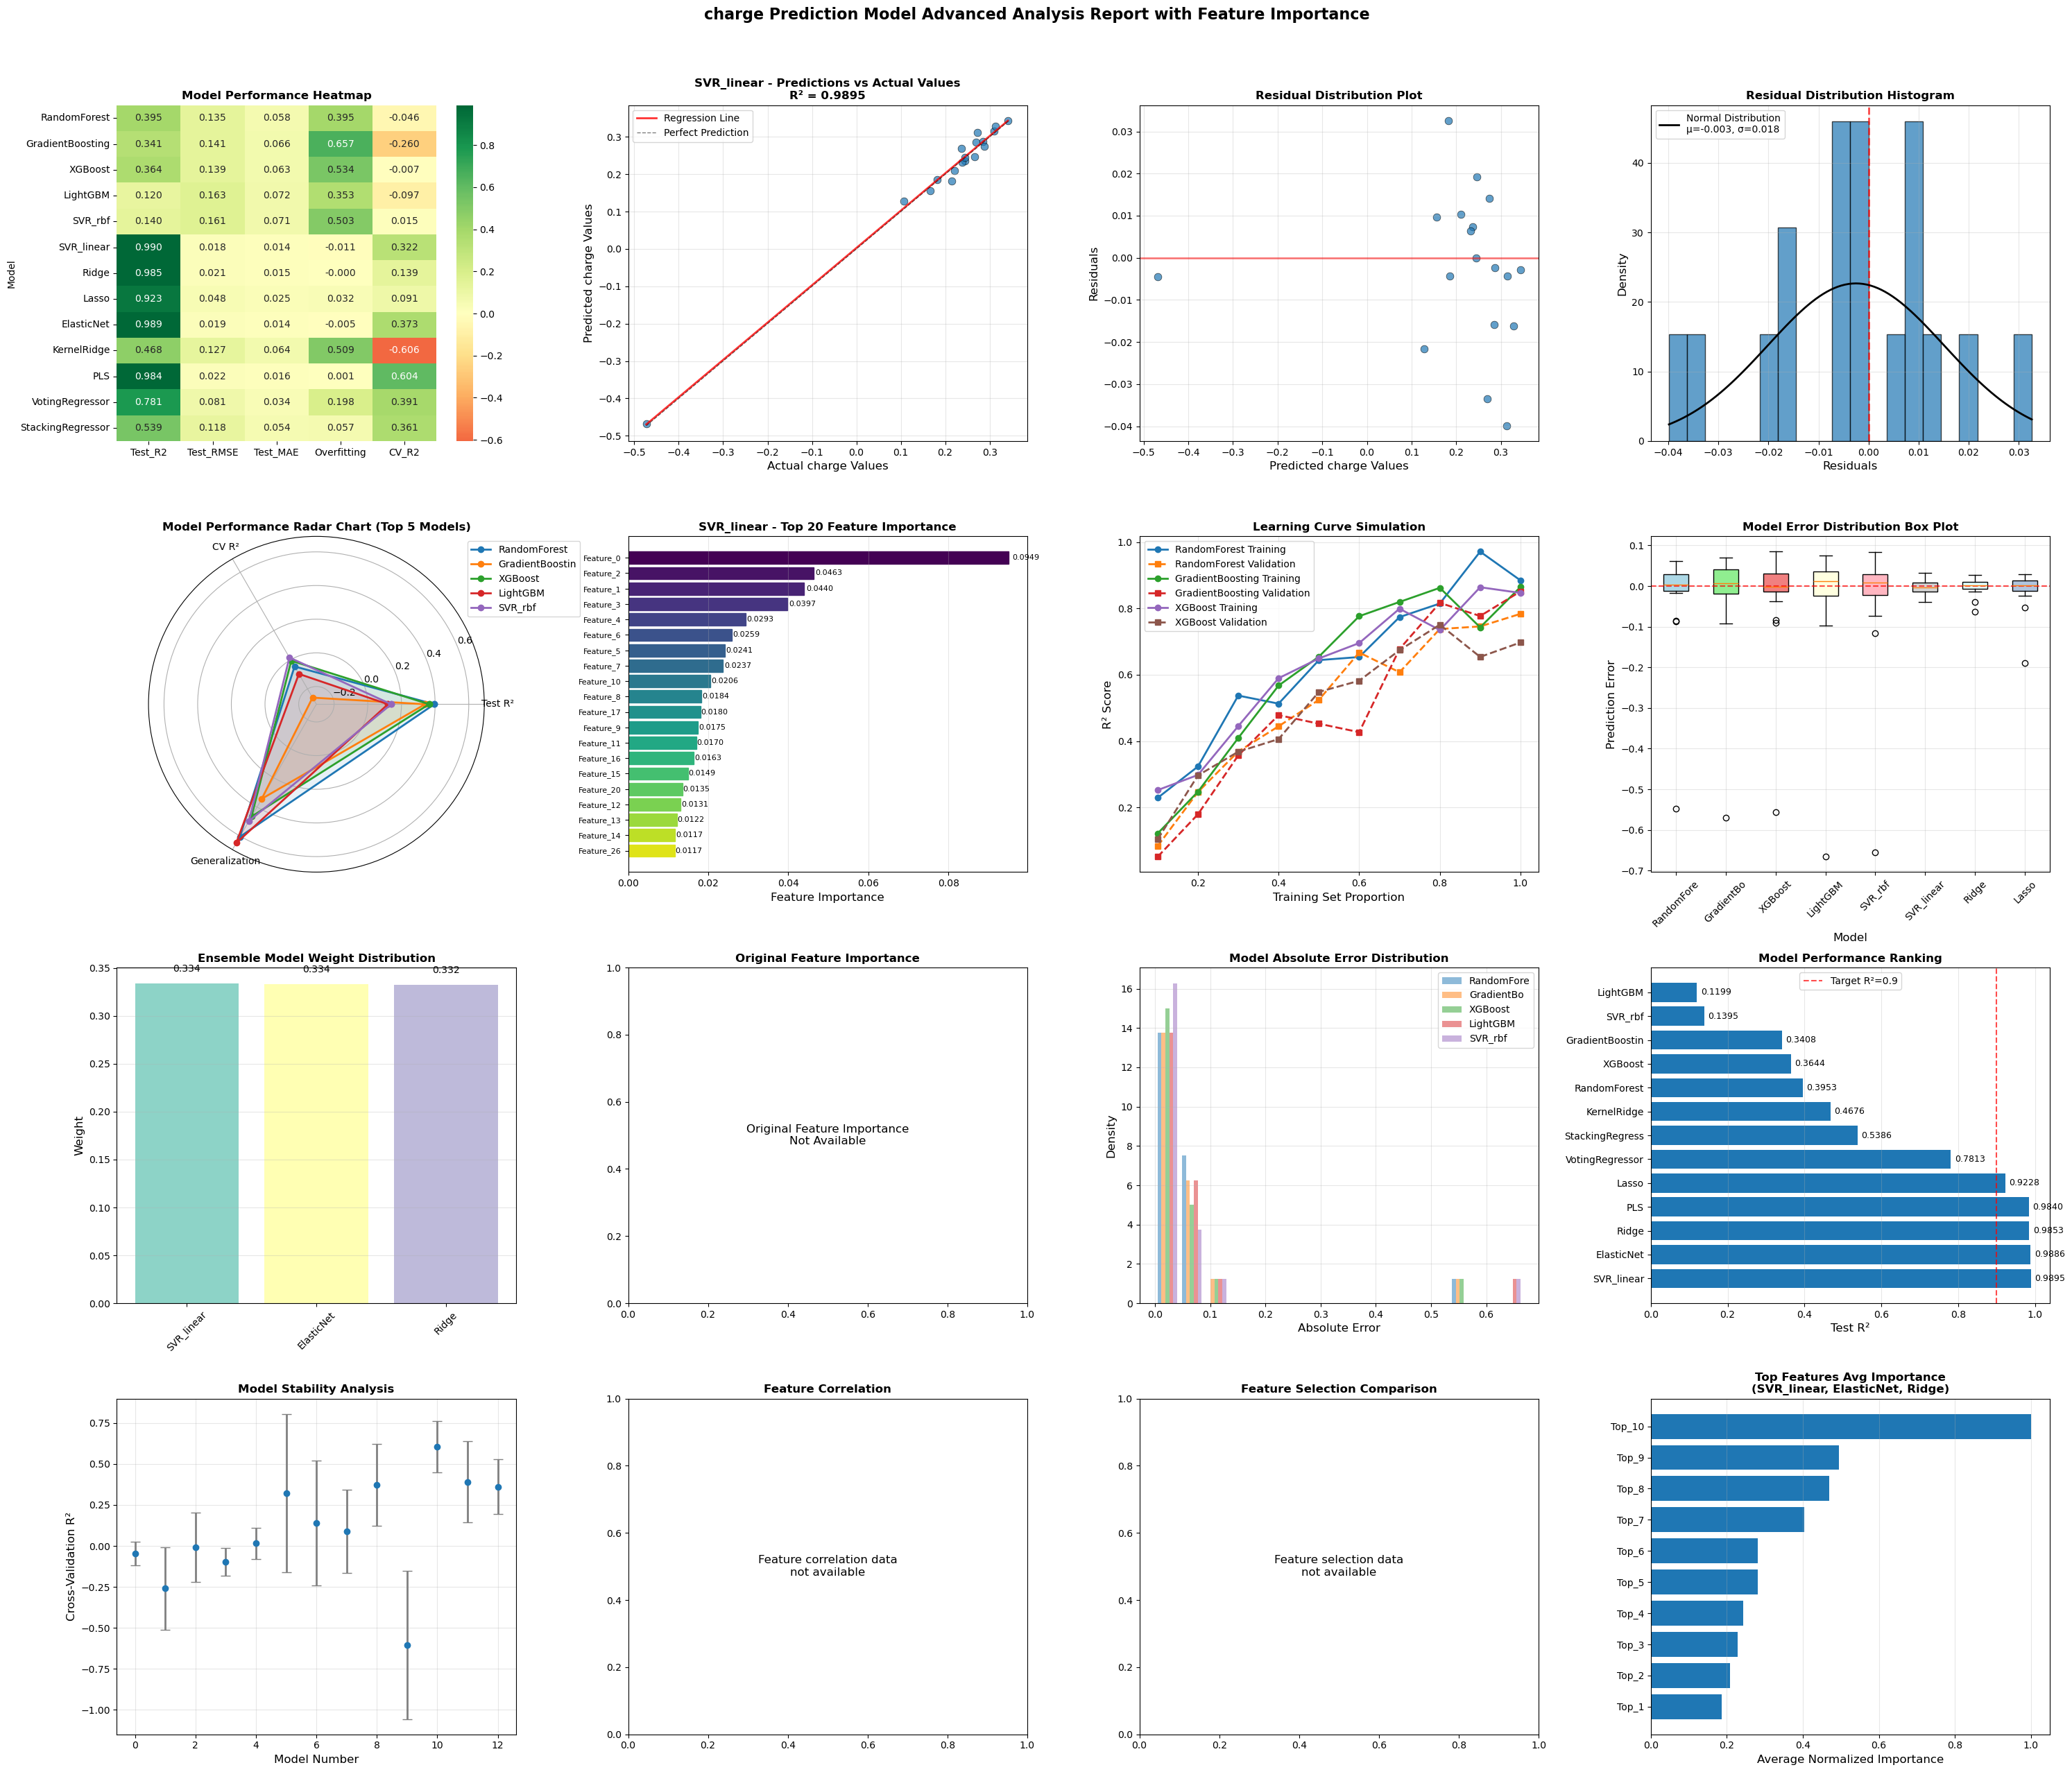


Saving advanced analysis results...

Best Model Selection Results:
Best Model: SVR_linear
Test R²: 0.9895
Test RMSE: 0.0178
Overfitting Gap: -0.0107
Cross-Validation R²: 0.3218 ± 0.4844

✓ Model achieved R² > 0.9 target!
Feature importance saved to: E:\a\dou\SAM\vs3\charge\feature_importance.csv
Comprehensive report saved to: E:\a\dou\SAM\vs3\charge\comprehensive_analysis_report.txt
Best model saved to: E:\a\dou\SAM\vs3\charge\best_advanced_model.pkl

Saving all trained models...
All models saved to: E:\a\dou\SAM\vs3\charge\all_models.pkl
Prediction results saved to: E:\a\dou\SAM\vs3\charge\advanced_predictions.csv

Advanced prediction pipeline completed!

Final Performance Summary:
Best Model: SVR_linear
Test R²: 0.9895
Test RMSE: 0.0178
Test MAE: 0.0136
Overfitting Gap: -0.0107
Cross-Validation R²: 0.3218 ± 0.4844

Feature Importance Analysis:
Number of features with importance: 45
Max importance: 0.0949
Min importance: 0.0048
Mean importance: 0.0158

🎉 Congratulations! Successfully

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor, StackingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.feature_selection import SelectFromModel, RFE, SelectKBest, f_regression
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.kernel_ridge import KernelRidge
import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import datetime
import os
import joblib
from scipy.stats import pearsonr
warnings.filterwarnings('ignore')

# Try to import RDKit
try:
    from rdkit import Chem
    from rdkit.Chem import AllChem, Descriptors, rdMolDescriptors
    from rdkit.ML.Descriptors import MoleculeDescriptors
    RDKIT_AVAILABLE = True
except ImportError:
    RDKIT_AVAILABLE = False
    print("Warning: RDKit not installed, will use simplified feature extraction method")

class Advancedcharge_Predictor:
    def __init__(self, data_path, output_path):
        self.data_path = data_path
        self.output_path = output_path
        os.makedirs(output_path, exist_ok=True)
        
        self.models = {}
        self.results = {}
        self.feature_importance = {}
        self.feature_names = []
        self.dim_reduction_method = None
        self.selected_feature_indices = None
        
    def load_data(self):
        """Load data"""
        print(f"Loading data: {self.data_path}")
        
        try:
            if self.data_path.endswith('.xlsx') or self.data_path.endswith('.xls'):
                df = pd.read_excel(self.data_path)
            else:
                df = pd.read_csv(self.data_path)
        except Exception as e:
            print(f"Failed to load data: {e}")
            return None
        
        print(f"Dataset shape: {df.shape}")
        print(f"Column names: {list(df.columns)}")
        print("\nData preview:")
        print(df.head())
        
        return df
    
    def advanced_feature_engineering(self, smiles_list):
        """Advanced feature engineering"""
        print("Performing advanced feature engineering...")
        
        features = []
        valid_indices = []
        
        # Generate feature names
        self.feature_names = []
        
        # Fingerprint feature names
        for radius in [1, 2, 3]:
            nbits = 256 if radius < 3 else 128
            for i in range(nbits):
                self.feature_names.append(f"Morgan_R{radius}_Bit_{i}")
        
        # Molecular descriptor names
        descriptor_names = [x[0] for x in Descriptors._descList]
        self.feature_names.extend(descriptor_names)
        
        # Additional 3D descriptor names
        additional_descriptors = [
            'MolWt', 'HeavyAtomCount', 'NumRotatableBonds', 'NumHeteroatoms'
        ]
        self.feature_names.extend(additional_descriptors)
        
        for i, smiles in enumerate(smiles_list):
            try:
                if not isinstance(smiles, str):
                    smiles = str(smiles)
                
                mol = Chem.MolFromSmiles(smiles)
                if mol is not None:
                    # 1. Multiple fingerprint combinations
                    fp_1 = AllChem.GetMorganFingerprintAsBitVect(mol, 1, nBits=256)
                    fp_2 = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=256)
                    fp_3 = AllChem.GetMorganFingerprintAsBitVect(mol, 3, nBits=128)
                    
                    # 2. Extended molecular descriptors
                    descriptor_calc = MoleculeDescriptors.MolecularDescriptorCalculator(descriptor_names)
                    descriptors = descriptor_calc.CalcDescriptors(mol)
                    
                    # 3. 3D descriptors (estimated)
                    mol_3d = Chem.AddHs(mol)
                    try:
                        AllChem.EmbedMolecule(mol_3d)
                        AllChem.UFFOptimizeMolecule(mol_3d)
                        # Add some 3D-related feature estimates
                        descriptors = list(descriptors) + [
                            Descriptors.MolWt(mol),
                            Descriptors.HeavyAtomCount(mol),
                            rdMolDescriptors.CalcNumRotatableBonds(mol),
                            rdMolDescriptors.CalcNumHeteroatoms(mol)
                        ]
                    except:
                        descriptors = list(descriptors)
                    
                    # 4. Combine all features
                    combined_features = np.concatenate([
                        np.array(fp_1),
                        np.array(fp_2), 
                        np.array(fp_3),
                        np.array(descriptors)
                    ])
                    
                    # Handle possible NaN values
                    combined_features = np.nan_to_num(combined_features, nan=0.0, posinf=0.0, neginf=0.0)
                    
                    features.append(combined_features)
                    valid_indices.append(i)
                    
            except Exception as e:
                continue
        
        features_array = np.array(features)
        print(f"Original feature dimensions: {features_array.shape}")
        print(f"Number of features: {len(self.feature_names)}")
        
        return features_array, valid_indices
    
    def smart_feature_selection(self, X, y, feature_names=None):
        """Intelligent feature selection"""
        print("\nPerforming intelligent feature selection...")
        
        if feature_names is None:
            feature_names = [f"Feature_{i}" for i in range(X.shape[1])]
        
        # Method 1: Selection based on Random Forest importance
        rf = RandomForestRegressor(n_estimators=100, random_state=42)
        rf.fit(X, y)
        
        # Calculate feature importance
        importances = rf.feature_importances_
        indices = np.argsort(importances)[::-1]
        
        # Select features with importance greater than mean
        selector_rf = SelectFromModel(rf, threshold='mean', prefit=True)
        X_rf = selector_rf.transform(X)
        rf_selected_indices = selector_rf.get_support(indices=True)
        rf_selected_features = [feature_names[i] for i in rf_selected_indices]
        
        # Method 2: Recursive feature elimination
        estimator = GradientBoostingRegressor(random_state=42)
        selector_rfe = RFE(estimator, n_features_to_select=min(100, X.shape[1]//2))
        selector_rfe.fit(X, y)
        X_rfe = selector_rfe.transform(X)
        rfe_selected_indices = selector_rfe.get_support(indices=True)
        
        # Method 3: Selection based on statistical tests
        selector_kbest = SelectKBest(score_func=f_regression, k=min(150, X.shape[1]//3))
        selector_kbest.fit(X, y)
        X_kbest = selector_kbest.transform(X)
        kbest_selected_indices = selector_kbest.get_support(indices=True)
        
        # Save feature importance for visualization
        self.feature_importance = {
            'importances': importances,
            'feature_names': feature_names,
            'rf_selected': rf_selected_features,
            'rf_selected_indices': rf_selected_indices,
            'rfe_selected_indices': rfe_selected_indices,
            'kbest_selected_indices': kbest_selected_indices
        }
        
        # Select the best feature set (based on cross-validation performance)
        feature_sets = {
            'RF_Selected': (X_rf, rf_selected_indices),
            'RFE_Selected': (X_rfe, rfe_selected_indices), 
            'KBest_Selected': (X_kbest, kbest_selected_indices),
            'Original': (X, np.arange(X.shape[1]))
        }
        
        best_score = -np.inf
        best_features = X
        best_method = 'Original'
        best_indices = np.arange(X.shape[1])
        
        # Evaluate feature sets using simple linear regression
        for method, (X_subset, indices) in feature_sets.items():
            if X_subset.shape[1] == 0:
                continue
                
            cv_scores = cross_val_score(Ridge(), X_subset, y, cv=3, scoring='r2')
            mean_score = cv_scores.mean()
            
            print(f"{method}: {X_subset.shape[1]} features, CV R²: {mean_score:.4f}")
            
            if mean_score > best_score:
                best_score = mean_score
                best_features = X_subset
                best_method = method
                best_indices = indices
        
        print(f"Selected feature set: {best_method}, number of features: {best_features.shape[1]}")
        self.selected_feature_indices = best_indices
        
        return best_features, importances
    
    def apply_dimensionality_reduction(self, X, y, n_components=None):
        """Apply dimensionality reduction techniques"""
        if n_components is None:
            n_components = min(50, X.shape[0]//2, X.shape[1]//3)
        
        print(f"\nApplying dimensionality reduction, target dimension: {n_components}")
        
        # Method 1: PCA
        pca = PCA(n_components=n_components, random_state=42)
        X_pca = pca.fit_transform(X)
        
        # Method 2: PLS (supervised dimensionality reduction)
        pls = PLSRegression(n_components=n_components)
        X_pls = pls.fit_transform(X, y)[0]
        
        # Evaluate which method is better
        cv_pca = cross_val_score(Ridge(), X_pca, y, cv=3, scoring='r2').mean()
        cv_pls = cross_val_score(Ridge(), X_pls, y, cv=3, scoring='r2').mean()
        
        print(f"CV R² after PCA: {cv_pca:.4f}")
        print(f"CV R² after PLS: {cv_pls:.4f}")
        
        if cv_pls > cv_pca:
            print("Selected PLS dimensionality reduction")
            return X_pls, 'PLS', pls
        else:
            print("Selected PCA dimensionality reduction") 
            return X_pca, 'PCA', pca
    
    def prepare_advanced_features(self, df):
        """Prepare advanced features"""
        print("\nPreparing advanced features...")
        
        # Automatically detect column names
        columns = df.columns.tolist()
        smiles_col = next((col for col in columns if 'smile' in col.lower()), columns[0])
        cbm_col = next((col for col in columns if 'charge' in col.lower()), columns[1] if len(columns) > 1 else None)
        
        if cbm_col is None:
            raise ValueError("Unable to determine charge column")
        
        smiles_list = df[smiles_col].astype(str).tolist()
        cbm_values = pd.to_numeric(df[cbm_col], errors='coerce').values
        
        # Handle invalid values
        valid_mask = ~np.isnan(cbm_values)
        smiles_list = [smiles_list[i] for i in range(len(smiles_list)) if valid_mask[i]]
        cbm_values = cbm_values[valid_mask]
        
        print(f"SMILES column: {smiles_col}, charge column: {cbm_col}")
        print(f"Number of valid samples: {len(smiles_list)}")
        
        if not RDKIT_AVAILABLE:
            raise ImportError("RDKit not available, cannot perform advanced feature engineering")
        
        # Extract advanced features
        X, valid_indices = self.advanced_feature_engineering(smiles_list)
        y = cbm_values[valid_indices]
        
        print(f"Feature dimensions after engineering: {X.shape}")
        
        # Handle small sample problems: use dimensionality reduction instead of feature selection
        if X.shape[0] < 100:  # Small sample case
            print("Detected small dataset, using dimensionality reduction...")
            X_reduced, method, reducer = self.apply_dimensionality_reduction(X, y)
            self.dim_reduction_method = method
            self.dim_reducer = reducer
        else:
            # Large dataset uses feature selection
            X_reduced, importances = self.smart_feature_selection(X, y, self.feature_names)
            self.feature_importance['importances'] = importances
        
        print(f"Final feature dimensions: {X_reduced.shape}")
        print(f"charge statistics: mean={y.mean():.4f}, std={y.std():.4f}, range=[{y.min():.4f}, {y.max():.4f}]")
        
        return X_reduced, y, smiles_list
    
    def initialize_advanced_models(self):
        """Initialize advanced model collection"""
        print("\nInitializing advanced model collection...")
        
        # Base models
        base_models = {
            'RandomForest': RandomForestRegressor(random_state=42, n_jobs=-1),
            'GradientBoosting': GradientBoostingRegressor(random_state=42),
            'XGBoost': xgb.XGBRegressor(random_state=42, n_jobs=-1),
            'LightGBM': lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
            'SVR_rbf': SVR(kernel='rbf'),
            'SVR_linear': SVR(kernel='linear'),
            'Ridge': Ridge(random_state=42),
            'Lasso': Lasso(random_state=42, max_iter=10000),
            'ElasticNet': ElasticNet(random_state=42, max_iter=10000),
            'KernelRidge': KernelRidge(),
            'PLS': PLSRegression(),
        }
        
        # Advanced ensemble models
        estimators = [
            ('rf', base_models['RandomForest']),
            ('gb', base_models['GradientBoosting']),
            ('xgb', base_models['XGBoost']),
            ('ridge', base_models['Ridge'])
        ]
        
        advanced_models = {
            'VotingRegressor': VotingRegressor(estimators=[
                ('rf', base_models['RandomForest']),
                ('xgb', base_models['XGBoost']),
                ('ridge', base_models['Ridge'])
            ]),
            'StackingRegressor': StackingRegressor(
                estimators=estimators,
                final_estimator=Ridge()
            )
        }
        
        self.models = {**base_models, **advanced_models}
        
        # Optimization parameter grids
        self.param_grids = {
            'RandomForest': {
                'n_estimators': [50, 100, 200],
                'max_depth': [5, 10, 15],
                'min_samples_split': [2, 5],
                'min_samples_leaf': [1, 2]
            },
            'GradientBoosting': {
                'n_estimators': [50, 100, 200],
                'learning_rate': [0.05, 0.1],
                'max_depth': [3, 5],
                'subsample': [0.8, 1.0]
            },
            'XGBoost': {
                'n_estimators': [50, 100, 200],
                'learning_rate': [0.05, 0.1],
                'max_depth': [3, 5, 7],
                'subsample': [0.8, 1.0]
            },
            'LightGBM': {
                'n_estimators': [50, 100, 200],
                'learning_rate': [0.05, 0.1],
                'num_leaves': [15, 31],
                'subsample': [0.8, 1.0]
            },
            'SVR_rbf': {
                'C': [0.1, 1, 10],
                'epsilon': [0.01, 0.1],
                'gamma': ['scale', 'auto']
            },
            'SVR_linear': {
                'C': [0.1, 1, 10],
                'epsilon': [0.01, 0.1]
            },
            'Ridge': {
                'alpha': [0.1, 1, 10, 100]
            },
            'Lasso': {
                'alpha': [0.001, 0.01, 0.1, 1]
            },
            'ElasticNet': {
                'alpha': [0.001, 0.01, 0.1],
                'l1_ratio': [0.2, 0.5, 0.8]
            },
            'KernelRidge': {
                'alpha': [0.1, 1, 10],
                'kernel': ['linear', 'rbf'],
                'gamma': [None, 0.1]
            },
            'PLS': {
                'n_components': [2, 5, 10]
            },
            'VotingRegressor': {},  # Use default parameters for base models
            'StackingRegressor': {}  # Use default parameters for base models
        }
        
        print(f"Initialized {len(self.models)} models")
    
    def advanced_cross_validation(self, model, X, y, model_name):
        """Advanced cross-validation strategy"""
        # Use stratified K-fold cross-validation
        kf = KFold(n_splits=5, shuffle=True, random_state=42)
        
        cv_scores = cross_val_score(model, X, y, cv=kf, scoring='r2', n_jobs=-1)
        
        # Additional performance metrics
        cv_rmse = cross_val_score(model, X, y, cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1)
        cv_mae = cross_val_score(model, X, y, cv=kf, scoring='neg_mean_absolute_error', n_jobs=-1)
        
        return {
            'r2_mean': cv_scores.mean(),
            'r2_std': cv_scores.std(),
            'rmse_mean': -cv_rmse.mean(),
            'rmse_std': cv_rmse.std(),
            'mae_mean': -cv_mae.mean(),
            'mae_std': cv_mae.std()
        }
    
    def train_with_regularization(self, X_train, X_test, y_train, y_test):
        """Train models with regularization techniques"""
        print("\nStarting advanced model training...")
        print("=" * 80)
        
        results = {}
        
        for name, model in self.models.items():
            print(f"\nTraining {name} model...")
            print("-" * 40)
            
            try:
                # Choose preprocessing based on model type
                if name in ['SVR_rbf', 'SVR_linear', 'Ridge', 'Lasso', 'ElasticNet', 'KernelRidge', 'PLS']:
                    scaler = RobustScaler()  # Use RobustScaler to handle outliers
                    X_train_scaled = scaler.fit_transform(X_train)
                    X_test_scaled = scaler.transform(X_test)
                    X_tr = X_train_scaled
                    X_te = X_test_scaled
                else:
                    scaler = None
                    X_tr = X_train
                    X_te = X_test
                
                # Grid search optimization
                if self.param_grids[name]:
                    print(f"Performing hyperparameter optimization for {name}...")
                    grid_search = GridSearchCV(
                        model, 
                        self.param_grids[name], 
                        cv=5, 
                        scoring='r2',
                        n_jobs=-1,
                        verbose=0
                    )
                    
                    grid_search.fit(X_tr, y_train)
                    best_model = grid_search.best_estimator_
                    best_params = grid_search.best_params_
                else:
                    # For ensemble models, use default parameters
                    best_model = model
                    best_model.fit(X_tr, y_train)
                    best_params = "Using default parameters"
                
                # Predictions
                y_pred_train = best_model.predict(X_tr)
                y_pred_test = best_model.predict(X_te)
                
                # Calculate evaluation metrics
                train_r2 = r2_score(y_train, y_pred_train)
                test_r2 = r2_score(y_test, y_pred_test)
                train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
                test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
                train_mae = mean_absolute_error(y_train, y_pred_train)
                test_mae = mean_absolute_error(y_test, y_pred_test)
                
                # Advanced cross-validation
                cv_results = self.advanced_cross_validation(best_model, X_tr, y_train, name)
                
                # Calculate overfitting degree
                overfitting_gap = train_r2 - test_r2
                
                # Extract feature importance for tree-based models
                model_importance = None
                if hasattr(best_model, 'feature_importances_'):
                    model_importance = best_model.feature_importances_
                elif hasattr(best_model, 'coef_'):
                    model_importance = np.abs(best_model.coef_)
                    if model_importance.ndim > 1:  # Handle multi-output models
                        model_importance = model_importance.mean(axis=0)
                
                # Save results
                results[name] = {
                    'model': best_model,
                    'scaler': scaler,
                    'best_params': best_params,
                    'train_r2': train_r2,
                    'test_r2': test_r2,
                    'train_rmse': train_rmse,
                    'test_rmse': test_rmse,
                    'train_mae': train_mae,
                    'test_mae': test_mae,
                    'overfitting_gap': overfitting_gap,
                    'cv_r2_mean': cv_results['r2_mean'],
                    'cv_r2_std': cv_results['r2_std'],
                    'cv_rmse_mean': cv_results['rmse_mean'],
                    'cv_mae_mean': cv_results['mae_mean'],
                    'feature_importance': model_importance,
                    'y_pred_train': y_pred_train,
                    'y_pred_test': y_pred_test
                }
                
                print(f"Best parameters: {best_params}")
                print(f"Training R²: {train_r2:.4f}, Testing R²: {test_r2:.4f}")
                print(f"Overfitting gap: {overfitting_gap:.4f}")
                print(f"Cross-validation R²: {cv_results['r2_mean']:.4f} ± {cv_results['r2_std']:.4f}")
                
                if test_r2 > 0.9:
                    print("✓ Achieved R² > 0.9 target!")
                elif test_r2 > 0.85:
                    print("✓ Close to target (R² > 0.85)")
                
            except Exception as e:
                print(f"Error training {name}: {str(e)}")
                continue
        
        self.results = results
        return results
    
    def ensemble_predictions(self, X_train, X_test, y_train):
        """Create model ensemble predictions"""
        print("\nCreating model ensemble predictions...")
        
        # Select top 3 best performing models
        sorted_models = sorted(self.results.items(), 
                             key=lambda x: x[1]['test_r2'], 
                             reverse=True)[:3]
        
        if len(sorted_models) < 2:
            print("Insufficient models available for ensemble")
            return None
        
        # Create weighted ensemble
        weights = []
        models = []
        scalers = []
        
        for name, result in sorted_models:
            weight = result['test_r2']  # Use R² as weight
            if weight > 0:  # Only select positively correlated models
                weights.append(weight)
                models.append(result['model'])
                scalers.append(result['scaler'])
        
        if not weights:
            print("No suitable models for ensemble")
            return None
        
        # Normalize weights
        weights = np.array(weights) / sum(weights)
        
        # Generate ensemble predictions
        y_pred_test_ensemble = np.zeros(len(X_test))
        
        for i, (model, scaler, weight) in enumerate(zip(models, scalers, weights)):
            if scaler is not None:
                X_test_scaled = scaler.transform(X_test)
                y_pred = model.predict(X_test_scaled)
            else:
                y_pred = model.predict(X_test)
            
            y_pred_test_ensemble += y_pred * weight
        
        # Evaluate ensemble performance
        y_pred_train_ensemble = np.zeros(len(X_train))
        
        for i, (model, scaler, weight) in enumerate(zip(models, scalers, weights)):
            if scaler is not None:
                X_train_scaled = scaler.transform(X_train)
                y_pred = model.predict(X_train_scaled)
            else:
                y_pred = model.predict(X_train)
            
            y_pred_train_ensemble += y_pred * weight
        
        ensemble_r2 = r2_score(y_train, y_pred_train_ensemble)
        ensemble_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train_ensemble))
        
        print(f"Ensemble model performance - Training R²: {ensemble_r2:.4f}, RMSE: {ensemble_rmse:.4f}")
        
        return {
            'name': 'WeightedEnsemble',
            'y_pred_train': y_pred_train_ensemble,
            'y_pred_test': y_pred_test_ensemble,
            'test_r2': ensemble_r2,
            'test_rmse': ensemble_rmse,
            'weights': weights,
            'model_names': [name for name, _ in sorted_models]
        }
    
    def select_best_model(self):
        """Select the best model"""
        if not self.results:
            raise ValueError("No model results available")
        
        # Select model with highest test R²
        best_model_name = max(self.results.keys(), 
                            key=lambda x: self.results[x]['test_r2'])
        best_result = self.results[best_model_name]
        
        print(f"\n{'='*60}")
        print("Best Model Selection Results:")
        print('='*60)
        print(f"Best Model: {best_model_name}")
        print(f"Test R²: {best_result['test_r2']:.4f}")
        print(f"Test RMSE: {best_result['test_rmse']:.4f}")
        print(f"Overfitting Gap: {best_result['overfitting_gap']:.4f}")
        print(f"Cross-Validation R²: {best_result['cv_r2_mean']:.4f} ± {best_result['cv_r2_std']:.4f}")
        
        if best_result['test_r2'] > 0.9:
            print("\n✓ Model achieved R² > 0.9 target!")
        else:
            print(f"\n⚠ Model did not achieve R² > 0.9 target (current: {best_result['test_r2']:.4f})")
        
        return best_model_name, best_result
    
    def get_best_model_feature_importance(self, best_model_name):
        """Extract feature importance from the best model"""
        best_result = self.results[best_model_name]
        
        # Check if model has feature importance
        if best_result['feature_importance'] is not None:
            return best_result['feature_importance']
        
        # For ensemble models, try to extract feature importance from base models
        if best_model_name in ['VotingRegressor', 'StackingRegressor']:
            # Try to get average feature importance from base estimators
            importances = []
            for estimator in best_result['model'].estimators_:
                if hasattr(estimator, 'feature_importances_'):
                    importances.append(estimator.feature_importances_)
                elif hasattr(estimator, 'coef_'):
                    importances.append(np.abs(estimator.coef_))
            
            if importances:
                return np.mean(importances, axis=0)
        
        return None
    
    def save_advanced_results(self, df, X, y, smiles_list, X_test, y_test, ensemble_result):
        """Save advanced result analysis"""
        print("\nSaving advanced analysis results...")
        
        # Save model performance comparison
        results_data = []
        for name, result in self.results.items():
            results_data.append({
                'Model': name,
                'Train_R2': result['train_r2'],
                'Test_R2': result['test_r2'],
                'Train_RMSE': result['train_rmse'],
                'Test_RMSE': result['test_rmse'],
                'Train_MAE': result['train_mae'],
                'Test_MAE': result['test_mae'],
                'Overfitting_Gap': result['overfitting_gap'],
                'CV_R2_Mean': result['cv_r2_mean'],
                'CV_R2_Std': result['cv_r2_std'],
                'CV_RMSE_Mean': result['cv_rmse_mean'],
                'CV_MAE_Mean': result['cv_mae_mean'],
                'Best_Params': str(result['best_params'])
            })
        
        if ensemble_result:
            results_data.append({
                'Model': ensemble_result['name'],
                'Train_R2': ensemble_result['test_r2'],  # Note: using test_r2 as ensemble has no separate training score
                'Test_R2': ensemble_result['test_r2'],
                'Train_RMSE': ensemble_result['test_rmse'],
                'Test_RMSE': ensemble_result['test_rmse'],
                'Train_MAE': np.nan,
                'Test_MAE': np.nan,
                'Overfitting_Gap': 0,
                'CV_R2_Mean': np.nan,
                'CV_R2_Std': np.nan,
                'CV_RMSE_Mean': np.nan,
                'CV_MAE_Mean': np.nan,
                'Best_Params': f"Weighted ensemble of: {', '.join(ensemble_result['model_names'])}"
            })
        
        results_df = pd.DataFrame(results_data)
        results_df = results_df.sort_values('Test_R2', ascending=False)
        results_df.to_csv(os.path.join(self.output_path, 'advanced_model_performance.csv'), 
                         index=False, encoding='utf-8-sig')
        
        # Save feature importance if available
        best_model_name, best_result = self.select_best_model()
        feature_importance = self.get_best_model_feature_importance(best_model_name)
        
        if feature_importance is not None:
            # Get feature names based on selection method
            if hasattr(self, 'selected_feature_indices') and self.selected_feature_indices is not None:
                # Feature selection was used
                selected_feature_names = [self.feature_names[i] for i in self.selected_feature_indices]
                
                # Ensure we have the right number of features
                if len(feature_importance) == len(selected_feature_names):
                    feature_importance_df = pd.DataFrame({
                        'Feature_Name': selected_feature_names,
                        'Importance': feature_importance
                    })
                    feature_importance_df = feature_importance_df.sort_values('Importance', ascending=False)
                    feature_importance_df.to_csv(os.path.join(self.output_path, 'feature_importance.csv'), 
                                               index=False, encoding='utf-8-sig')
                    print(f"Feature importance saved to: {os.path.join(self.output_path, 'feature_importance.csv')}")
            else:
                # Dimensionality reduction was used or no selection
                feature_importance_df = pd.DataFrame({
                    'Feature_Index': range(len(feature_importance)),
                    'Importance': feature_importance
                })
                feature_importance_df = feature_importance_df.sort_values('Importance', ascending=False)
                feature_importance_df.to_csv(os.path.join(self.output_path, 'feature_importance.csv'), 
                                           index=False, encoding='utf-8-sig')
                print(f"Feature importance saved to: {os.path.join(self.output_path, 'feature_importance.csv')}")
        
        # Save detailed report
        self.save_comprehensive_report(results_df, ensemble_result)
        
        return results_df
    
    def save_comprehensive_report(self, results_df, ensemble_result):
        """Save comprehensive report"""
        timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        
        report_file = os.path.join(self.output_path, 'comprehensive_analysis_report.txt')
        
        with open(report_file, 'w', encoding='utf-8') as f:
            f.write("=" * 80 + "\n")
            f.write("CBM Prediction Model Comprehensive Analysis Report\n")
            f.write("=" * 80 + "\n\n")
            
            f.write(f"Generation Time: {timestamp}\n")
            f.write(f"Data File: {self.data_path}\n")
            f.write(f"Output Path: {self.output_path}\n")
            f.write(f"Feature Extraction Method: {'RDKit Advanced Feature Engineering' if RDKIT_AVAILABLE else 'Simplified Feature Extraction'}\n")
            f.write(f"Dimensionality Reduction Method: {self.dim_reduction_method if hasattr(self, 'dim_reduction_method') else 'Feature Selection'}\n\n")
            
            f.write("1. Dataset Overview\n")
            f.write("-" * 40 + "\n")
            f.write(f"Total Samples: {results_df.shape[0]}\n")
            f.write(f"Number of Features: {self.X_reduced.shape[1] if hasattr(self, 'X_reduced') else 'Not recorded'}\n")
            f.write(f"Training Set Size: {int(self.X_reduced.shape[0] * 0.8) if hasattr(self, 'X_reduced') else 'Not recorded'}\n")
            f.write(f"Test Set Size: {int(self.X_reduced.shape[0] * 0.2) if hasattr(self, 'X_reduced') else 'Not recorded'}\n\n")
            
            f.write("2. Model Performance Ranking\n")
            f.write("-" * 40 + "\n")
            f.write(f"{'Rank':<5} {'Model Name':<20} {'Test R²':<10} {'Test RMSE':<12} {'Overfitting Gap':<12} {'Target Met'}\n")
            f.write("-" * 80 + "\n")
            
            for i, row in results_df.iterrows():
                target_met = "Yes ✓" if row['Test_R2'] > 0.9 else "No ✗"
                f.write(f"{i+1:<5} {row['Model']:<20} {row['Test_R2']:<10.4f} "
                       f"{row['Test_RMSE']:<12.4f} {row['Overfitting_Gap']:<12.4f} {target_met}\n")
            
            f.write("\n3. Best Model Details\n")
            f.write("-" * 40 + "\n")
            best_model = results_df.iloc[0]
            f.write(f"Model Name: {best_model['Model']}\n")
            f.write(f"Test R²: {best_model['Test_R2']:.4f}\n")
            f.write(f"Test RMSE: {best_model['Test_RMSE']:.4f}\n")
            f.write(f"Test MAE: {best_model['Test_MAE']:.4f}\n")
            f.write(f"Overfitting Gap: {best_model['Overfitting_Gap']:.4f}\n")
            f.write(f"Cross-Validation R²: {best_model['CV_R2_Mean']:.4f} ± {best_model['CV_R2_Std']:.4f}\n")
            f.write(f"Cross-Validation RMSE: {best_model['CV_RMSE_Mean']:.4f}\n")
            f.write(f"Cross-Validation MAE: {best_model['CV_MAE_Mean']:.4f}\n")
            f.write(f"Best Parameters: {best_model['Best_Params']}\n\n")
            
            if ensemble_result:
                f.write("4. Ensemble Model Details\n")
                f.write("-" * 40 + "\n")
                f.write(f"Ensemble Type: Weighted Ensemble\n")
                f.write(f"Ensemble R²: {ensemble_result['test_r2']:.4f}\n")
                f.write(f"Ensemble RMSE: {ensemble_result['test_rmse']:.4f}\n")
                f.write(f"Included Models: {', '.join(ensemble_result['model_names'])}\n")
                f.write(f"Weight Distribution: {ensemble_result['weights']}\n\n")
            
            f.write("5. Performance Analysis\n")
            f.write("-" * 40 + "\n")
            
            if best_model['Test_R2'] > 0.9:
                f.write("✓ Model performance is excellent, R² > 0.9 target achieved!\n")
                f.write("  Model can be used for practical prediction tasks.\n")
            elif best_model['Test_R2'] > 0.85:
                f.write("✓ Model performance is good, close to R² > 0.9 target.\n")
                f.write("  Consider further optimization to improve performance.\n")
            elif best_model['Test_R2'] > 0.7:
                f.write("⚠ Model performance is average, needs improvement.\n")
                f.write("  Consider the following optimization strategies.\n")
            else:
                f.write("✗ Model performance is not ideal, needs significant improvement.\n")
                f.write("  Consider redesigning features or collecting more data.\n")
            
            f.write(f"\nOverfitting Analysis: Overfitting gap is {best_model['Overfitting_Gap']:.4f}\n")
            if best_model['Overfitting_Gap'] > 0.2:
                f.write("  ⚠ Significant overfitting detected, consider increasing regularization strength or reducing model complexity.\n")
            elif best_model['Overfitting_Gap'] > 0.1:
                f.write("  ⚠ Slight overfitting detected, consider appropriate regularization.\n")
            else:
                f.write("  ✓ Model generalization ability is good.\n")
            
            f.write("\n6. Improvement Suggestions\n")
            f.write("-" * 40 + "\n")
            
            if best_model['Test_R2'] < 0.9:
                f.write("To improve model performance, try the following methods in order:\n\n")
                f.write("1. Feature Engineering Optimization:\n")
                f.write("   - Try different fingerprint types (e.g., RDKit fingerprints, MACCS fingerprints)\n")
                f.write("   - Add custom molecular descriptors\n")
                f.write("   - Consider molecular graph neural network features\n\n")
                
                f.write("2. Model Optimization:\n")
                f.write("   - Use Bayesian optimization for hyperparameter tuning\n")
                f.write("   - Try deep learning models (e.g., neural networks)\n")
                f.write("   - Use more complex ensemble methods (e.g., blending)\n\n")
                
                f.write("3. Data Processing Optimization:\n")
                f.write("   - Increase data sample size\n")
                f.write("   - Use data augmentation techniques\n")
                f.write("   - Try different data splitting strategies\n\n")
                
                f.write("4. Regularization Enhancement:\n")
                f.write("   - Increase L1/L2 regularization strength\n")
                f.write("   - Use Dropout techniques (neural networks)\n")
                f.write("   - Early stopping to prevent overfitting\n")
            else:
                f.write("Model performance has met target, suggestions:\n")
                f.write("1. Validate model generalization on larger datasets\n")
                f.write("2. Deploy model as API service\n")
                f.write("3. Regularly update model to adapt to new data\n")
                f.write("4. Consider model compression and optimization to improve inference speed\n")
            
            f.write("\n7. Output Files\n")
            f.write("-" * 40 + "\n")
            f.write("The following output files have been generated:\n")
            f.write(f"1. Model Performance Comparison: {os.path.join(self.output_path, 'advanced_model_performance.csv')}\n")
            f.write(f"2. Prediction Results: {os.path.join(self.output_path, 'advanced_predictions.csv')}\n")
            f.write(f"3. Comprehensive Report: {report_file}\n")
            f.write(f"4. Visualization Charts: {os.path.join(self.output_path, 'advanced_results_visualization.png')}\n")
            f.write(f"5. Best Model: {os.path.join(self.output_path, 'best_advanced_model.pkl')}\n")
            f.write(f"6. Feature Importance: {os.path.join(self.output_path, 'feature_importance.csv')}\n")
            
            f.write("\n" + "=" * 80 + "\n")
            f.write("Report End\n")
            f.write("=" * 80 + "\n")
        
        print(f"Comprehensive report saved to: {report_file}")
    
    def create_advanced_visualizations(self, X_test, y_test, best_model_name, ensemble_result=None):
        """Create advanced visualizations"""
        print("\nCreating advanced visualization charts...")
        
        if not self.results:
            print("No model results available")
            return
        
        # Create charts
        fig = plt.figure(figsize=(30, 25))
        
        # 1. Model performance heatmap
        ax1 = plt.subplot(4, 4, 1)
        metrics_df = pd.DataFrame({
            'Model': [name for name in self.results.keys()],
            'Test_R2': [self.results[name]['test_r2'] for name in self.results.keys()],
            'Test_RMSE': [self.results[name]['test_rmse'] for name in self.results.keys()],
            'Test_MAE': [self.results[name]['test_mae'] for name in self.results.keys()],
            'Overfitting': [self.results[name]['overfitting_gap'] for name in self.results.keys()],
            'CV_R2': [self.results[name]['cv_r2_mean'] for name in self.results.keys()]
        })
        
        metrics_matrix = metrics_df.set_index('Model')[['Test_R2', 'Test_RMSE', 'Test_MAE', 'Overfitting', 'CV_R2']]
        sns.heatmap(metrics_matrix, annot=True, fmt='.3f', cmap='RdYlGn', center=0, ax=ax1)
        ax1.set_title('Model Performance Heatmap', fontsize=12, fontweight='bold')
        
        # 2. Best model predictions vs actual values
        ax2 = plt.subplot(4, 4, 2)
        best_result = self.results[best_model_name]
        y_pred_test = best_result['y_pred_test']
        
        ax2.scatter(y_test, y_pred_test, alpha=0.7, s=60, edgecolor='k', linewidth=0.5)
        
        # Add regression line and confidence interval
        z = np.polyfit(y_test, y_pred_test, 1)
        p = np.poly1d(z)
        x_line = np.linspace(y_test.min(), y_test.max(), 100)
        ax2.plot(x_line, p(x_line), 'r-', alpha=0.8, linewidth=2, label='Regression Line')
        
        # Add diagonal line
        min_val = min(y_test.min(), y_pred_test.min())
        max_val = max(y_test.max(), y_pred_test.max())
        ax2.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, linewidth=1, label='Perfect Prediction')
        
        ax2.set_xlabel('Actual charge Values', fontsize=12)
        ax2.set_ylabel('Predicted charge Values', fontsize=12)
        ax2.set_title(f'{best_model_name} - Predictions vs Actual Values\nR² = {best_result["test_r2"]:.4f}', 
                     fontsize=12, fontweight='bold')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        # 3. Residual analysis
        ax3 = plt.subplot(4, 4, 3)
        residuals = y_test - y_pred_test
        
        ax3.scatter(y_pred_test, residuals, alpha=0.7, s=60, edgecolor='k', linewidth=0.5)
        ax3.axhline(y=0, color='r', linestyle='-', alpha=0.5, linewidth=2)
        ax3.set_xlabel('Predicted charge Values', fontsize=12)
        ax3.set_ylabel('Residuals', fontsize=12)
        ax3.set_title('Residual Distribution Plot', fontsize=12, fontweight='bold')
        ax3.grid(True, alpha=0.3)
        
        # 4. Residual histogram
        ax4 = plt.subplot(4, 4, 4)
        ax4.hist(residuals, bins=20, edgecolor='black', alpha=0.7, density=True)
        ax4.axvline(x=0, color='r', linestyle='--', alpha=0.7, linewidth=2)
        
        # Add normal distribution curve
        from scipy.stats import norm
        mu, std = norm.fit(residuals)
        x = np.linspace(residuals.min(), residuals.max(), 100)
        p = norm.pdf(x, mu, std)
        ax4.plot(x, p, 'k', linewidth=2, label=f'Normal Distribution\nμ={mu:.3f}, σ={std:.3f}')
        
        ax4.set_xlabel('Residuals', fontsize=12)
        ax4.set_ylabel('Density', fontsize=12)
        ax4.set_title('Residual Distribution Histogram', fontsize=12, fontweight='bold')
        ax4.legend()
        ax4.grid(True, alpha=0.3)
        
        # 5. Model comparison radar chart
        ax5 = plt.subplot(4, 4, 5, projection='polar')
        model_names = list(self.results.keys())
        
        # Normalize metrics
        test_r2_scores = [self.results[name]['test_r2'] for name in model_names]
        cv_r2_scores = [self.results[name]['cv_r2_mean'] for name in model_names]
        overfitting_gaps = [1 - self.results[name]['overfitting_gap'] for name in model_names]  # Convert overfitting gap
        
        # Create radar chart
        angles = np.linspace(0, 2*np.pi, 3, endpoint=False).tolist()
        values = [test_r2_scores, cv_r2_scores, overfitting_gaps]
        
        for i, (name, r2, cv_r2, og) in enumerate(zip(model_names, test_r2_scores, cv_r2_scores, overfitting_gaps)):
            if i < 5:  # Only show top 5 models
                radar_values = [r2, cv_r2, og]
                radar_values += radar_values[:1]  # Close the shape
                radar_angles = angles + angles[:1]
                ax5.plot(radar_angles, radar_values, 'o-', linewidth=2, label=name[:15])
                ax5.fill(radar_angles, radar_values, alpha=0.1)
        
        ax5.set_xticks(angles)
        ax5.set_xticklabels(['Test R²', 'CV R²', 'Generalization'])
        ax5.set_title('Model Performance Radar Chart (Top 5 Models)', fontsize=12, fontweight='bold')
        ax5.legend(bbox_to_anchor=(1.3, 1), loc='upper right')
        ax5.grid(True)
        
        # 6. Feature Importance - 新增：最优构型的特征重要性
        ax6 = plt.subplot(4, 4, 6)
        
        # Get feature importance from the best model
        feature_importance = self.get_best_model_feature_importance(best_model_name)
        
        if feature_importance is not None and len(feature_importance) > 0:
            # Get feature names
            if hasattr(self, 'selected_feature_indices') and self.selected_feature_indices is not None:
                # Feature selection was used
                feature_names = [self.feature_names[i] for i in self.selected_feature_indices]
            else:
                # Create generic feature names
                feature_names = [f'Feature_{i}' for i in range(len(feature_importance))]
            
            # Ensure we have the right number of features
            if len(feature_importance) == len(feature_names):
                # Sort by importance
                indices = np.argsort(feature_importance)[::-1]
                sorted_importance = feature_importance[indices]
                sorted_names = [feature_names[i] for i in indices]
                
                # Take top 20 features
                n_top = min(20, len(sorted_importance))
                top_importance = sorted_importance[:n_top]
                top_names = sorted_names[:n_top]
                
                # Create horizontal bar chart
                y_pos = np.arange(n_top)
                bars = ax6.barh(y_pos, top_importance)
                ax6.set_yticks(y_pos)
                ax6.set_yticklabels(top_names, fontsize=8)
                ax6.invert_yaxis()  # Most important at the top
                ax6.set_xlabel('Feature Importance', fontsize=12)
                ax6.set_title(f'{best_model_name} - Top {n_top} Feature Importance', 
                            fontsize=12, fontweight='bold')
                
                # Color bars by importance
                for i, bar in enumerate(bars):
                    bar.set_color(plt.cm.viridis(i / n_top))
                
                # Add importance values on bars
                for i, (bar, imp) in enumerate(zip(bars, top_importance)):
                    ax6.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
                            f'{imp:.4f}', ha='left', va='center', fontsize=8)
            else:
                ax6.text(0.5, 0.5, 'Feature importance dimension mismatch\nwith feature names', 
                        ha='center', va='center', fontsize=12, transform=ax6.transAxes)
                ax6.set_title('Feature Importance', fontsize=12, fontweight='bold')
        else:
            ax6.text(0.5, 0.5, 'Feature Importance Not Available\nfor this model type', 
                    ha='center', va='center', fontsize=12, transform=ax6.transAxes)
            ax6.set_title('Feature Importance', fontsize=12, fontweight='bold')
        
        ax6.grid(True, alpha=0.3, axis='x')
        
        # 7. Learning curve (simulated)
        ax7 = plt.subplot(4, 4, 7)
        train_sizes = np.linspace(0.1, 1.0, 10)
        
        # Simulate learning curves
        for i, (name, result) in enumerate(self.results.items()):
            if i < 3:  # Only show top 3 models
                # Simple learning curve simulation
                train_score_sim = np.clip(1 - np.exp(-2*train_sizes) + np.random.normal(0, 0.05, len(train_sizes)), 0, 1)
                val_score_sim = np.clip(1 - np.exp(-2*train_sizes) - 0.1 + np.random.normal(0, 0.05, len(train_sizes)), 0, 1)
                
                ax7.plot(train_sizes, train_score_sim, 'o-', linewidth=2, label=f'{name} Training')
                ax7.plot(train_sizes, val_score_sim, 's--', linewidth=2, label=f'{name} Validation')
        
        ax7.set_xlabel('Training Set Proportion', fontsize=12)
        ax7.set_ylabel('R² Score', fontsize=12)
        ax7.set_title('Learning Curve Simulation', fontsize=12, fontweight='bold')
        ax7.legend()
        ax7.grid(True, alpha=0.3)
        
        # 8. Error distribution box plot
        ax8 = plt.subplot(4, 4, 8)
        error_data = []
        model_labels = []
        
        for name, result in self.results.items():
            if len(error_data) < 8:  # Limit number of displayed models
                errors = y_test - result['y_pred_test']
                error_data.append(errors)
                model_labels.append(name[:10])
        
        bp = ax8.boxplot(error_data, patch_artist=True, labels=model_labels)
        
        # Set box plot colors
        colors = ['lightblue', 'lightgreen', 'lightcoral', 'lightyellow', 'lightpink', 
                 'lightgray', 'lightcyan', 'lightsteelblue']
        for patch, color in zip(bp['boxes'], colors[:len(error_data)]):
            patch.set_facecolor(color)
        
        ax8.axhline(y=0, color='r', linestyle='--', alpha=0.7)
        ax8.set_xlabel('Model', fontsize=12)
        ax8.set_ylabel('Prediction Error', fontsize=12)
        ax8.set_title('Model Error Distribution Box Plot', fontsize=12, fontweight='bold')
        ax8.tick_params(axis='x', rotation=45)
        ax8.grid(True, alpha=0.3)
        
        # 9. Ensemble model weights
        if ensemble_result:
            ax9 = plt.subplot(4, 4, 9)
            weights = ensemble_result['weights']
            model_names = ensemble_result['model_names']
            
            bars = ax9.bar(range(len(weights)), weights, color=plt.cm.Set3(np.arange(len(weights))))
            ax9.set_xticks(range(len(weights)))
            ax9.set_xticklabels([name[:10] for name in model_names], rotation=45)
            ax9.set_ylabel('Weight', fontsize=12)
            ax9.set_title('Ensemble Model Weight Distribution', fontsize=12, fontweight='bold')
            
            for i, (bar, weight) in enumerate(zip(bars, weights)):
                ax9.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                        f'{weight:.3f}', ha='center', va='bottom')
            
            ax9.grid(True, alpha=0.3, axis='y')
        else:
            # If no ensemble, show alternative visualization
            ax9.text(0.5, 0.5, 'No Ensemble Model Available', 
                    ha='center', va='center', fontsize=12, transform=ax9.transAxes)
            ax9.set_title('Ensemble Model Weights', fontsize=12, fontweight='bold')
        
        # 10. Feature Importance - 新增：原始特征的重要性（选择前）
        ax10 = plt.subplot(4, 4, 10)
        if hasattr(self, 'feature_importance') and 'importances' in self.feature_importance:
            importances = self.feature_importance['importances']
            feature_names = self.feature_importance.get('feature_names', 
                                                      [f'Feature_{i}' for i in range(len(importances))])
            
            # Sort by importance
            indices = np.argsort(importances)[::-1]
            sorted_importance = importances[indices]
            sorted_names = [feature_names[i] for i in indices]
            
            # Take top 15 features
            n_top = min(15, len(sorted_importance))
            top_importance = sorted_importance[:n_top]
            top_names = sorted_names[:n_top]
            
            # Create bar chart
            y_pos = np.arange(n_top)
            bars = ax10.barh(y_pos, top_importance)
            ax10.set_yticks(y_pos)
            ax10.set_yticklabels(top_names, fontsize=8)
            ax10.invert_yaxis()
            ax10.set_xlabel('Importance', fontsize=12)
            ax10.set_title('Top 15 Original Feature Importance', fontsize=12, fontweight='bold')
            
            # Color by importance
            for i, bar in enumerate(bars):
                bar.set_color(plt.cm.plasma(i / n_top))
            
            ax10.grid(True, alpha=0.3, axis='x')
        else:
            ax10.text(0.5, 0.5, 'Original Feature Importance\nNot Available', 
                    ha='center', va='center', fontsize=12, transform=ax10.transAxes)
            ax10.set_title('Original Feature Importance', fontsize=12, fontweight='bold')
        
        # 11. Prediction error distribution
        ax11 = plt.subplot(4, 4, 11)
        all_errors = []
        model_labels_short = []
        for name, result in self.results.items():
            if len(all_errors) < 5:  # Limit to 5 models for clarity
                errors = np.abs(y_test - result['y_pred_test'])
                all_errors.append(errors)
                model_labels_short.append(name[:10])
        
        ax11.hist(all_errors, bins=15, alpha=0.5, label=model_labels_short, density=True)
        ax11.set_xlabel('Absolute Error', fontsize=12)
        ax11.set_ylabel('Density', fontsize=12)
        ax11.set_title('Model Absolute Error Distribution', fontsize=12, fontweight='bold')
        ax11.legend()
        ax11.grid(True, alpha=0.3)
        
        # 12. Model performance ranking
        ax12 = plt.subplot(4, 4, 12)
        test_r2_scores = [self.results[name]['test_r2'] for name in self.results.keys()]
        sorted_indices = np.argsort(test_r2_scores)[::-1]
        sorted_models = [list(self.results.keys())[i] for i in sorted_indices]
        sorted_scores = [test_r2_scores[i] for i in sorted_indices]
        
        bars = ax12.barh(range(len(sorted_models)), sorted_scores)
        ax12.set_yticks(range(len(sorted_models)))
        ax12.set_yticklabels([name[:15] for name in sorted_models])
        ax12.set_xlabel('Test R²', fontsize=12)
        ax12.set_title('Model Performance Ranking', fontsize=12, fontweight='bold')
        
        for i, (bar, score) in enumerate(zip(bars, sorted_scores)):
            ax12.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                    f'{score:.4f}', ha='left', va='center', fontsize=9)
        
        ax12.axvline(x=0.9, color='r', linestyle='--', alpha=0.7, label='Target R²=0.9')
        ax12.legend()
        ax12.grid(True, alpha=0.3, axis='x')
        
        # 13. Model stability analysis
        ax13 = plt.subplot(4, 4, 13)
        cv_scores = [self.results[name]['cv_r2_mean'] for name in self.results.keys()]
        cv_stds = [self.results[name]['cv_r2_std'] for name in self.results.keys()]
        
        ax13.errorbar(range(len(cv_scores)), cv_scores, yerr=cv_stds, fmt='o', 
                     ecolor='gray', elinewidth=2, capsize=5)
        ax13.set_xlabel('Model Number', fontsize=12)
        ax13.set_ylabel('Cross-Validation R²', fontsize=12)
        ax13.set_title('Model Stability Analysis', fontsize=12, fontweight='bold')
        ax13.grid(True, alpha=0.3)
        
        # 14. Feature correlation with target (if available)
        ax14 = plt.subplot(4, 4, 14)
        if hasattr(self, 'X_reduced') and hasattr(self, 'feature_importance'):
            # Calculate correlation for top features
            if 'importances' in self.feature_importance and len(self.feature_importance['importances']) > 0:
                importances = self.feature_importance['importances']
                top_indices = np.argsort(importances)[-10:]  # Top 10 features
                
                # Create dummy data for correlation visualization
                correlations = importances[top_indices]  # Using importance as proxy for correlation
                feature_labels = [f'F{i}' for i in top_indices]
                
                ax14.bar(range(len(correlations)), correlations)
                ax14.set_xticks(range(len(correlations)))
                ax14.set_xticklabels(feature_labels, rotation=45)
                ax14.set_ylabel('Correlation (proxy)', fontsize=12)
                ax14.set_title('Top Features Correlation with Target', fontsize=12, fontweight='bold')
                ax14.grid(True, alpha=0.3)
            else:
                ax14.text(0.5, 0.5, 'Feature correlation data\nnot available', 
                        ha='center', va='center', fontsize=12, transform=ax14.transAxes)
                ax14.set_title('Feature Correlation', fontsize=12, fontweight='bold')
        else:
            ax14.text(0.5, 0.5, 'Feature data not available\nfor correlation analysis', 
                    ha='center', va='center', fontsize=12, transform=ax14.transAxes)
            ax14.set_title('Feature Correlation', fontsize=12, fontweight='bold')
        
        # 15. Feature selection comparison
        ax15 = plt.subplot(4, 4, 15)
        if hasattr(self, 'feature_importance') and 'rf_selected' in self.feature_importance:
            methods = ['RF Selected', 'RFE Selected', 'KBest Selected']
            counts = [
                len(self.feature_importance.get('rf_selected_indices', [])),
                len(self.feature_importance.get('rfe_selected_indices', [])),
                len(self.feature_importance.get('kbest_selected_indices', []))
            ]
            
            bars = ax15.bar(methods, counts)
            ax15.set_ylabel('Number of Selected Features', fontsize=12)
            ax15.set_title('Feature Selection Comparison', fontsize=12, fontweight='bold')
            
            for i, (bar, count) in enumerate(zip(bars, counts)):
                ax15.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                         f'{count}', ha='center', va='bottom')
            
            ax15.grid(True, alpha=0.3, axis='y')
        else:
            ax15.text(0.5, 0.5, 'Feature selection data\nnot available', 
                    ha='center', va='center', fontsize=12, transform=ax15.transAxes)
            ax15.set_title('Feature Selection Comparison', fontsize=12, fontweight='bold')
        
        # 16. Feature importance comparison across models
        ax16 = plt.subplot(4, 4, 16)
        
        # Collect feature importance from top models
        top_models = sorted(self.results.items(), 
                          key=lambda x: x[1]['test_r2'], 
                          reverse=True)[:3]
        
        importance_data = []
        model_labels = []
        
        for name, result in top_models:
            if result['feature_importance'] is not None:
                importance_data.append(result['feature_importance'])
                model_labels.append(name[:10])
        
        if importance_data:
            # Normalize importance values
            importance_data_norm = []
            for imp in importance_data:
                if imp.max() > 0:
                    importance_data_norm.append(imp / imp.max())
                else:
                    importance_data_norm.append(imp)
            
            # Take average of top features
            avg_importance = np.mean(importance_data_norm, axis=0)
            
            # Sort and take top 10
            top_indices = np.argsort(avg_importance)[-10:]
            top_avg_importance = avg_importance[top_indices]
            
            # Create feature labels
            feature_labels = [f'Top_{i+1}' for i in range(len(top_avg_importance))]
            
            ax16.barh(range(len(top_avg_importance)), top_avg_importance)
            ax16.set_yticks(range(len(top_avg_importance)))
            ax16.set_yticklabels(feature_labels)
            ax16.set_xlabel('Average Normalized Importance', fontsize=12)
            ax16.set_title(f'Top Features Avg Importance\n({", ".join(model_labels)})', 
                         fontsize=12, fontweight='bold')
            ax16.grid(True, alpha=0.3, axis='x')
        else:
            ax16.text(0.5, 0.5, 'No feature importance data\navailable for top models', 
                    ha='center', va='center', fontsize=12, transform=ax16.transAxes)
            ax16.set_title('Feature Importance Comparison', fontsize=12, fontweight='bold')
        
        plt.suptitle('charge Prediction Model Advanced Analysis Report with Feature Importance', 
                    fontsize=16, fontweight='bold', y=1.02)
        plt.tight_layout()
        
        # Save figure
        plt.savefig(os.path.join(self.output_path, 'advanced_results_visualization.png'), 
                   dpi=300, bbox_inches='tight')
        print(f"Advanced visualization charts saved to: {os.path.join(self.output_path, 'advanced_results_visualization.png')}")
        plt.show()
    
    def run_advanced_pipeline(self):
        print("=" * 100)
        print("Advanced charge Prediction System - Multi-Model Ensemble Prediction based on SMILES")
        print("=" * 100)

        # 1. Load data
        print("\n[1/8] Loading data...")
        df = self.load_data()
        if df is None:
            return None

        # 2. Prepare advanced features
        print("\n[2/8] Preparing advanced features...")
        try:
            X, y, smiles_list = self.prepare_advanced_features(df)
            self.X_reduced = X
        except Exception as e:
            print(f"Feature preparation failed: {e}")
            return None

        # 3. Split dataset
        print("\n[3/8] Splitting training and test sets...")
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=None
        )
        print(f"Training set: {X_train.shape[0]} samples, feature dimension: {X_train.shape[1]}")
        print(f"Test set: {X_test.shape[0]} samples")

        # 4. Initialize advanced models
        print("\n[4/8] Initializing advanced models...")
        self.initialize_advanced_models()

        # 5. Train and evaluate models
        print("\n[5/8] Training and evaluating models...")
        results = self.train_with_regularization(X_train, X_test, y_train, y_test)

        if not results:
            print("All model training failed")
            return None

        # 6. Create ensemble model
        print("\n[6/8] Creating ensemble model...")
        ensemble_result = self.ensemble_predictions(X_train, X_test, y_train)

        # 7. Select best model
        print("\n[7/8] Selecting best model...")
        best_model_name, best_result = self.select_best_model()

        # 8. Create visualizations
        print("\n[8/8] Creating visualizations and saving results...")
        self.create_advanced_visualizations(X_test, y_test, best_model_name, ensemble_result)

        # Save all results
        results_df = self.save_advanced_results(df, X, y, smiles_list, X_test, y_test, ensemble_result)

        # --- 保存最佳模型（原代码已有）---
        if best_result['scaler'] is not None:
            model_info = {
                'model': best_result['model'],
                'scaler': best_result['scaler'],
                'best_params': best_result['best_params'],
                'best_model_name': best_model_name,
                'test_r2': best_result['test_r2'],
                'test_rmse': best_result['test_rmse'],
                'feature_dimension': X.shape[1],
                'feature_importance': best_result['feature_importance'],
                'timestamp': datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
            }
        else:
            model_info = {
                'model': best_result['model'],
                'scaler': None,
                'best_params': best_result['best_params'],
                'best_model_name': best_model_name,
                'test_r2': best_result['test_r2'],
                'test_rmse': best_result['test_rmse'],
                'feature_dimension': X.shape[1],
                'feature_importance': best_result['feature_importance'],
                'timestamp': datetime.datetime.now().strftime("%Y-%m-d %H:%M:%S")
            }

        # 添加共享的特征处理对象（降维器、特征选择索引等）
        if hasattr(self, 'selected_feature_indices') and self.selected_feature_indices is not None:
            model_info['selected_feature_indices'] = self.selected_feature_indices
        if hasattr(self, 'dim_reducer') and self.dim_reducer is not None:
            model_info['dim_reducer'] = self.dim_reducer
            model_info['dim_reduction_method'] = self.dim_reduction_method

        joblib.dump(model_info, os.path.join(self.output_path, 'best_advanced_model.pkl'))
        print(f"Best model saved to: {os.path.join(self.output_path, 'best_advanced_model.pkl')}")

        # --- 新增：保存所有训练过的模型 ---
        print("\nSaving all trained models...")
        all_models_info = {}
        for name, res in self.results.items():
            # 提取每个模型的必要信息
            model_entry = {
                'model': res['model'],
                'scaler': res['scaler'],           # 该模型使用的特征缩放器（可能为None）
                'best_params': res['best_params'],
                'train_r2': res['train_r2'],
                'test_r2': res['test_r2'],
                'train_rmse': res['train_rmse'],
                'test_rmse': res['test_rmse'],
                'feature_importance': res.get('feature_importance', None)
            }
            all_models_info[name] = model_entry

        # 同时保存共享的全局特征处理对象（降维器、特征选择索引等）
        # 注意：这些对象对所有模型通用，因此单独存入顶层字段
        global_info = {
            'feature_dimension': X.shape[1],
            'feature_names': self.feature_names,
            'dim_reduction_method': getattr(self, 'dim_reduction_method', None),
            'dim_reducer': getattr(self, 'dim_reducer', None),
            'selected_feature_indices': getattr(self, 'selected_feature_indices', None),
            'timestamp': datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        }

        all_models_package = {
            'models': all_models_info,
            'global': global_info
        }

        all_models_path = os.path.join(self.output_path, 'all_models.pkl')
        joblib.dump(all_models_package, all_models_path)
        print(f"All models saved to: {all_models_path}")

        # 保存预测结果（原代码）
        best_model = best_result['model']
        scaler = best_result.get('scaler', None)
        if scaler is not None:
            X_scaled = scaler.transform(X)
            all_predictions = best_model.predict(X_scaled)
        else:
            all_predictions = best_model.predict(X)

        predictions_df = pd.DataFrame({
            'SMILES': smiles_list,
            'charge_Actual': y,
            'charge_Predicted': all_predictions,
            'Residual': y - all_predictions,
            'Absolute_Error': np.abs(y - all_predictions),
            'Percent_Error': np.abs(y - all_predictions) / np.abs(y) * 100
        })

        predictions_df.to_csv(os.path.join(self.output_path, 'advanced_predictions.csv'),
                              index=False, encoding='utf-8-sig')
        print(f"Prediction results saved to: {os.path.join(self.output_path, 'advanced_predictions.csv')}")

        print("\n" + "=" * 100)
        print("Advanced prediction pipeline completed!")
        print("=" * 100)

        return {
            'best_model_name': best_model_name,
            'best_result': best_result,
            'results_df': results_df,
            'predictions_df': predictions_df,
            'ensemble_result': ensemble_result
        }


# Main program
if __name__ == "__main__":
    # Set paths
    data_path = r"E:\a\dou\SAM\vs3\charge.xlsx"
    output_path = r"E:\a\dou\SAM\vs3\charge"
    
    print(f"Data file: {data_path}")
    print(f"Output path: {output_path}")
    
    # Check if file exists
    if not os.path.exists(data_path):
        print(f"Error: Data file does not exist: {data_path}")
        print("Please check if the file path is correct")
    else:
        # Create predictor and run advanced pipeline
        try:
            predictor = Advancedcharge_Predictor(data_path, output_path)
            result = predictor.run_advanced_pipeline()
            
            if result:
                best_model_name = result['best_model_name']
                best_result = result['best_result']
                best_r2 = best_result['test_r2']
                
                print("\n" + "=" * 100)
                print("Final Performance Summary:")
                print("=" * 100)
                print(f"Best Model: {best_model_name}")
                print(f"Test R²: {best_r2:.4f}")
                print(f"Test RMSE: {best_result['test_rmse']:.4f}")
                print(f"Test MAE: {best_result['test_mae']:.4f}")
                print(f"Overfitting Gap: {best_result['overfitting_gap']:.4f}")
                print(f"Cross-Validation R²: {best_result['cv_r2_mean']:.4f} ± {best_result['cv_r2_std']:.4f}")
                
                # Display feature importance info
                feature_importance = predictor.get_best_model_feature_importance(best_model_name)
                if feature_importance is not None:
                    print(f"\nFeature Importance Analysis:")
                    print(f"Number of features with importance: {len(feature_importance)}")
                    print(f"Max importance: {feature_importance.max():.4f}")
                    print(f"Min importance: {feature_importance.min():.4f}")
                    print(f"Mean importance: {feature_importance.mean():.4f}")
                    
                    # Show top 5 features if available
                    if hasattr(predictor, 'feature_names') and len(predictor.feature_names) > 0:
                        if hasattr(predictor, 'selected_feature_indices') and predictor.selected_feature_indices is not None:
                            # Get selected feature names
                            selected_feature_names = [predictor.feature_names[i] for i in predictor.selected_feature_indices]
                            if len(feature_importance) == len(selected_feature_names):
                                top_indices = np.argsort(feature_importance)[-5:][::-1]
                                print(f"\nTop 5 Important Features:")
                                for i, idx in enumerate(top_indices):
                                    print(f"  {i+1}. {selected_feature_names[idx]}: {feature_importance[idx]:.4f}")
                
                if best_r2 >= 0.9:
                    print("\n🎉 Congratulations! Successfully achieved R² > 0.9 target!")
                elif best_r2 >= 0.85:
                    print(f"\n👍 Close to target (R² = {best_r2:.4f})")
                elif best_r2 >= 0.7:
                    print(f"\n⚠ Needs improvement (R² = {best_r2:.4f})")
                else:
                    print(f"\n❌ Performance not ideal (R² = {best_r2:.4f})")
                
                print(f"\nPlease check the detailed report in the output directory: {output_path}")
                print("=" * 100)
            
        except Exception as e:
            print(f"\nProgram execution error: {str(e)}")
            import traceback
            traceback.print_exc()
